# EfficientNet-B0 Transfer Learning for Waste Classification

## Smart Waste Classification System Using Deep Learning

This notebook implements and evaluates an EfficientNet-B0 transfer-learning
model for classifying waste images from the TrashNet dataset.

The experiment is part of the model-development stage of the Smart Waste
Classification System. The results obtained in this notebook will later be
compared with the following architectures:

- Baseline Convolutional Neural Network
- ResNet50
- EfficientNet-B0
- DenseNet121
- MobileNetV3

The EfficientNet-B0 model will be trained in two stages:

1. Frozen feature extraction
2. Controlled fine-tuning

The final evaluation will include classification performance, per-class
behavior, model size, inference latency, and error analysis.

In [41]:
import json
import os
import platform
import random
import sys
import time

from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import torch
import torch.nn as nn
import torchvision

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
)

from PIL import Image, UnidentifiedImageError
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms

In [3]:
print("=" * 70)
print("EXECUTION ENVIRONMENT")
print("=" * 70)

print(f"Python executable : {sys.executable}")
print(f"Python version    : {platform.python_version()}")
print(f"PyTorch version   : {torch.__version__}")
print(f"TorchVision       : {torchvision.__version__}")
print(f"Operating system  : {platform.platform()}")

print("-" * 70)

print(f"CUDA available    : {torch.cuda.is_available()}")

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Selected device   : {DEVICE}")

if DEVICE.type == "cuda":
    print(f"GPU name          : {torch.cuda.get_device_name(0)}")
else:
    print("Hardware note     : CPU-only training environment")

print("=" * 70)

EXECUTION ENVIRONMENT
Python executable : c:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\.venv\Scripts\python.exe
Python version    : 3.12.10
PyTorch version   : 2.13.0+cpu
TorchVision       : 0.28.0+cpu
Operating system  : Windows-11-10.0.26200-SP0
----------------------------------------------------------------------
CUDA available    : False
Selected device   : cpu
Hardware note     : CPU-only training environment


In [4]:
SEED = 42


def set_random_seed(seed: int) -> None:
    """
    Configure random seeds for Python, NumPy, and PyTorch.

    Parameters
    ----------
    seed:
        Integer used to initialize random number generators.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


set_random_seed(SEED)

print(f"Random seed configured successfully: {SEED}")

Random seed configured successfully: 42


In [5]:
EXPERIMENT_NAME = "efficientnet_b0"
MODEL_VERSION = "1.0.0"

IMAGE_HEIGHT = 224
IMAGE_WIDTH = 224
IMAGE_SIZE = (IMAGE_HEIGHT, IMAGE_WIDTH)

BATCH_SIZE = 16
NUM_WORKERS = 0

HEAD_EPOCHS = 10
FINE_TUNE_EPOCHS = 5

HEAD_LEARNING_RATE = 1e-3
FINE_TUNE_LEARNING_RATE = 1e-5

WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.30

PROJECT_ROOT = Path("..")

MODEL_DIRECTORY = PROJECT_ROOT / "models"
RESULTS_DIRECTORY = PROJECT_ROOT / "results"
FIGURES_DIRECTORY = RESULTS_DIRECTORY / "figures"
LOGS_DIRECTORY = PROJECT_ROOT / "logs"

MODEL_DIRECTORY.mkdir(parents=True, exist_ok=True)
RESULTS_DIRECTORY.mkdir(parents=True, exist_ok=True)
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)
LOGS_DIRECTORY.mkdir(parents=True, exist_ok=True)

FROZEN_CHECKPOINT_PATH = (
    MODEL_DIRECTORY / "efficientnet_b0_frozen_best.pt"
)

FINE_TUNED_CHECKPOINT_PATH = (
    MODEL_DIRECTORY / "efficientnet_b0_finetuned_best.pt"
)

print(f"Experiment name : {EXPERIMENT_NAME}")
print(f"Model version   : {MODEL_VERSION}")
print(f"Image size      : {IMAGE_SIZE}")
print(f"Batch size      : {BATCH_SIZE}")
print(f"Device          : {DEVICE}")

Experiment name : efficientnet_b0
Model version   : 1.0.0
Image size      : (224, 224)
Batch size      : 16
Device          : cpu


In [6]:
DATA_DIRECTORY = PROJECT_ROOT / "data"
RAW_DATA_DIRECTORY = DATA_DIRECTORY / "raw" / "trashnet"
SPLITS_DIRECTORY = DATA_DIRECTORY / "splits"

SPLIT_MANIFEST_PATH = (
    SPLITS_DIRECTORY / "split_manifest.csv"
)

print("Dataset paths")
print("-" * 70)
print(f"Raw dataset directory : {RAW_DATA_DIRECTORY.resolve()}")
print(f"Split manifest        : {SPLIT_MANIFEST_PATH.resolve()}")

Dataset paths
----------------------------------------------------------------------
Raw dataset directory : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\raw\trashnet
Split manifest        : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv


In [7]:
DATA_DIRECTORY = PROJECT_ROOT / "data"
RAW_DATA_DIRECTORY = DATA_DIRECTORY / "raw" / "trashnet"
SPLITS_DIRECTORY = DATA_DIRECTORY / "splits"

SPLIT_MANIFEST_PATH = (
    SPLITS_DIRECTORY / "split_manifest.csv"
)

print("Dataset paths")
print("-" * 70)
print(f"Raw dataset directory : {RAW_DATA_DIRECTORY.resolve()}")
print(f"Split manifest        : {SPLIT_MANIFEST_PATH.resolve()}")

Dataset paths
----------------------------------------------------------------------
Raw dataset directory : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\raw\trashnet
Split manifest        : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\splits\split_manifest.csv


In [9]:
required_paths = {
    "Raw TrashNet directory": RAW_DATA_DIRECTORY,
    "Dataset split manifest": SPLIT_MANIFEST_PATH,
}

path_validation_records = []

for path_name, path_value in required_paths.items():
    path_validation_records.append(
        {
            "resource": path_name,
            "path": str(path_value.resolve()),
            "exists": path_value.exists(),
        }
    )

path_validation_table = pd.DataFrame(
    path_validation_records
)

path_validation_table

,resource,path,exists
0,Raw TrashNet directory,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,True
1,Dataset split manifest,C:\Users\Mudassar Iqbal Shah\Documents\Interns...,True


In [10]:
missing_paths = [
    path_name
    for path_name, path_value in required_paths.items()
    if not path_value.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "The following required project resources are missing: "
        + ", ".join(missing_paths)
    )

print("All required dataset paths were found successfully.")

All required dataset paths were found successfully.


In [11]:
split_manifest = pd.read_csv(
    SPLIT_MANIFEST_PATH
)

print(
    f"Manifest loaded successfully: "
    f"{len(split_manifest):,} rows"
)

split_manifest.head()

Manifest loaded successfully: 2,521 rows


,class_name,split,source_path,destination_path,sha256
0,cardboard,train,data\raw\trashnet\cardboard\cardboard235.jpg,data\processed\train\cardboard\cardboard235.jpg,d550d9d6c2b831d3dee5bb985a259a4f872df22baaf2a1...
1,cardboard,train,data\raw\trashnet\cardboard\cardboard213.jpg,data\processed\train\cardboard\cardboard213.jpg,b3c979a3f4b7246548b51ee34782dfab7e146a569511f6...
2,cardboard,train,data\raw\trashnet\cardboard\cardboard169.jpg,data\processed\train\cardboard\cardboard169.jpg,a6b0a3670259dd8027b06e87ae292e8eca1c87634d785e...
3,cardboard,train,data\raw\trashnet\cardboard\cardboard138.jpg,data\processed\train\cardboard\cardboard138.jpg,7d70edc60cfb2c34a6c9d636200d39f61b0c5d7ed4a69b...
4,cardboard,train,data\raw\trashnet\cardboard\cardboard334.jpg,data\processed\train\cardboard\cardboard334.jpg,e20217c46a83b281bcda09e3d2679e22292d3e3c25bc93...


In [12]:
print("Manifest columns:")
print(split_manifest.columns.tolist())

print("\nManifest shape:")
print(split_manifest.shape)

print("\nManifest data types:")
print(split_manifest.dtypes)

Manifest columns:
['class_name', 'split', 'source_path', 'destination_path', 'sha256']

Manifest shape:
(2521, 5)

Manifest data types:
class_name          str
split               str
source_path         str
destination_path    str
sha256              str
dtype: object


In [13]:
pd.set_option(
    "display.max_colwidth",
    None,
)

split_manifest.sample(
    n=min(10, len(split_manifest)),
    random_state=SEED,
)

,class_name,split,source_path,destination_path,sha256
196,cardboard,train,data\raw\trashnet\cardboard\cardboard61.jpg,data\processed\train\cardboard\cardboard61.jpg,f5ddc7f1e11d9192efb6618268afe867fab4546550e4a7ff2139b1698dbb2cfc
986,metal,train,data\raw\trashnet\metal\metal66.jpg,data\processed\train\metal\metal66.jpg,22389a79d35d5e8d121394e093dd723724e2184fd007f4c03b98c43b8c8fa48a
1090,metal,train,data\raw\trashnet\metal\metal389.jpg,data\processed\train\metal\metal389.jpg,33ed5bedbe97a9b8244afc1603b335cb88b397475eb0a064f542fd7d0a0193ec
387,cardboard,test,data\raw\trashnet\cardboard\cardboard294.jpg,data\processed\test\cardboard\cardboard294.jpg,1928c692335255284b24fb66446d694cc8b0ff360db60ddd21662f25158d07d4
2222,plastic,train,data\raw\trashnet\plastic\plastic296.jpg,data\processed\train\plastic\plastic296.jpg,b351129a596213f3b020cb63230fa6e0698e9fe20f9b8bb9d023f4ecf3aa436c
168,cardboard,train,data\raw\trashnet\cardboard\cardboard217.jpg,data\processed\train\cardboard\cardboard217.jpg,3f5fba27f5c8a3e46bdbcbccb8e42ff38514e6bd5b6ac3aac96a8d44a05e52ea
1378,paper,train,data\raw\trashnet\paper\paper172.jpg,data\processed\train\paper\paper172.jpg,846cd3a2d5456ebcd00a66353cdd8f4bac1055eb0910a87a9e7b9493aa780492
2463,trash,train,data\raw\trashnet\trash\trash49.jpg,data\processed\train\trash\trash49.jpg,bb30f9f1cbbfd077d079cc10e55c3724c1f479c467bca875a76a5a15d274d3e7
705,glass,train,data\raw\trashnet\glass\glass133.jpg,data\processed\train\glass\glass133.jpg,9bd5eb02f2f0b1d3c188621c7d32bb8d7b3924f408060c0f36cd6f92febc366b
2076,plastic,train,data\raw\trashnet\plastic\plastic215.jpg,data\processed\train\plastic\plastic215.jpg,a3858f8eeb36befa8c708c87e52bdb7bc9bdd20b73a4375fe6a856ca23ce6262


In [14]:
missing_value_summary = pd.DataFrame(
    {
        "missing_values": (
            split_manifest.isna().sum()
        ),
        "missing_percentage": (
            split_manifest.isna().mean() * 100
        ),
    }
)

missing_value_summary

,missing_values,missing_percentage
class_name,0,0.0
split,0,0.0
source_path,0,0.0
destination_path,0,0.0
sha256,0,0.0


In [15]:
duplicate_row_count = int(
    split_manifest.duplicated().sum()
)

print(
    f"Exact duplicate manifest rows: "
    f"{duplicate_row_count}"
)

Exact duplicate manifest rows: 0


In [16]:
column_names_lower = {
    column.lower(): column
    for column in split_manifest.columns
}

possible_path_columns = [
    column
    for column in split_manifest.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "path",
            "file",
            "image",
        ]
    )
]

possible_class_columns = [
    column
    for column in split_manifest.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "class",
            "label",
            "category",
        ]
    )
]

possible_split_columns = [
    column
    for column in split_manifest.columns
    if any(
        keyword in column.lower()
        for keyword in [
            "split",
            "subset",
            "partition",
        ]
    )
]

print("Possible image-path columns:")
print(possible_path_columns)

print("\nPossible class columns:")
print(possible_class_columns)

print("\nPossible split columns:")
print(possible_split_columns)

Possible image-path columns:
['source_path', 'destination_path']

Possible class columns:
['class_name']

Possible split columns:
['split']


In [17]:
for column in split_manifest.columns:
    unique_count = split_manifest[column].nunique(
        dropna=False
    )

    if unique_count <= 20:
        print("=" * 70)
        print(f"Column: {column}")
        print(f"Unique values: {unique_count}")
        print(
            split_manifest[column]
            .value_counts(dropna=False)
        )

Column: class_name
Unique values: 6
class_name
paper        594
glass        498
plastic      480
metal        409
cardboard    403
trash        137
Name: count, dtype: int64
Column: split
Unique values: 3
split
train         1762
test           381
validation     378
Name: count, dtype: int64


In [18]:
PATH_COLUMN = "destination_path"
CLASS_COLUMN = "class_name"
SPLIT_COLUMN = "split"

required_manifest_columns = {
    PATH_COLUMN,
    CLASS_COLUMN,
    SPLIT_COLUMN,
}

missing_manifest_columns = (
    required_manifest_columns
    - set(split_manifest.columns)
)

if missing_manifest_columns:
    raise KeyError(
        "The manifest is missing required columns: "
        + ", ".join(sorted(missing_manifest_columns))
    )

print("Required manifest columns verified.")
print(f"Path column  : {PATH_COLUMN}")
print(f"Class column : {CLASS_COLUMN}")
print(f"Split column : {SPLIT_COLUMN}")

Required manifest columns verified.
Path column  : destination_path
Class column : class_name
Split column : split


In [19]:
split_manifest[
    [
        CLASS_COLUMN,
        SPLIT_COLUMN,
        PATH_COLUMN,
    ]
].head(10)

,class_name,split,destination_path
0,cardboard,train,data\processed\train\cardboard\cardboard235.jpg
1,cardboard,train,data\processed\train\cardboard\cardboard213.jpg
2,cardboard,train,data\processed\train\cardboard\cardboard169.jpg
3,cardboard,train,data\processed\train\cardboard\cardboard138.jpg
4,cardboard,train,data\processed\train\cardboard\cardboard334.jpg
5,cardboard,train,data\processed\train\cardboard\cardboard160.jpg
6,cardboard,train,data\processed\train\cardboard\cardboard71.jpg
7,cardboard,train,data\processed\train\cardboard\cardboard352.jpg
8,cardboard,train,data\processed\train\cardboard\cardboard26.jpg
9,cardboard,train,data\processed\train\cardboard\cardboard307.jpg


In [20]:
first_manifest_path = split_manifest.loc[
    0,
    PATH_COLUMN,
]

print("Stored path:")
print(first_manifest_path)

print("\nPath type:")
print(type(first_manifest_path))

Stored path:
data\processed\train\cardboard\cardboard235.jpg

Path type:
<class 'str'>


In [21]:
def resolve_image_path(
    stored_path: str,
    project_root: Path,
) -> Path:
    """
    Convert a manifest path into an absolute filesystem path.

    Parameters
    ----------
    stored_path:
        Image path stored in the split manifest.

    project_root:
        Root directory of the project.

    Returns
    -------
    Path
        Resolved absolute image path.
    """
    image_path = Path(stored_path)

    if image_path.is_absolute():
        return image_path

    return (project_root / image_path).resolve()

In [22]:
resolved_example_path = resolve_image_path(
    first_manifest_path,
    PROJECT_ROOT,
)

print("Resolved image path:")
print(resolved_example_path)

print("\nFile exists:")
print(resolved_example_path.exists())

Resolved image path:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train\cardboard\cardboard235.jpg

File exists:
True


In [23]:
split_manifest = split_manifest.copy()

split_manifest["resolved_path"] = (
    split_manifest[PATH_COLUMN]
    .apply(
        lambda stored_path: resolve_image_path(
            stored_path=stored_path,
            project_root=PROJECT_ROOT,
        )
    )
)

split_manifest["file_exists"] = (
    split_manifest["resolved_path"]
    .apply(Path.exists)
)

path_existence_summary = (
    split_manifest["file_exists"]
    .value_counts(dropna=False)
    .rename_axis("file_exists")
    .reset_index(name="image_count")
)

path_existence_summary

,file_exists,image_count
0,True,2521


In [24]:
missing_image_records = split_manifest[
    split_manifest["file_exists"] == False
].copy()

if not missing_image_records.empty:
    print(
        missing_image_records[
            [
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
                "resolved_path",
            ]
        ].head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_image_records)} manifest images "
        "could not be found."
    )

print(
    f"All {len(split_manifest):,} manifest images "
    "were found successfully."
)

All 2,521 manifest images were found successfully.


In [25]:
EXPECTED_SPLITS = {
    "train",
    "validation",
    "test",
}

actual_splits = set(
    split_manifest[SPLIT_COLUMN].unique()
)

unexpected_splits = (
    actual_splits - EXPECTED_SPLITS
)

missing_splits = (
    EXPECTED_SPLITS - actual_splits
)

if unexpected_splits:
    raise ValueError(
        "Unexpected split labels found: "
        + ", ".join(sorted(unexpected_splits))
    )

if missing_splits:
    raise ValueError(
        "Required split labels are missing: "
        + ", ".join(sorted(missing_splits))
    )

print("Dataset split labels verified:")
print(sorted(actual_splits))

Dataset split labels verified:
['test', 'train', 'validation']


In [26]:
hash_split_counts = (
    split_manifest
    .groupby("sha256")[SPLIT_COLUMN]
    .nunique()
)

cross_split_hashes = hash_split_counts[
    hash_split_counts > 1
]

print(
    "Image hashes appearing in multiple splits:",
    len(cross_split_hashes),
)

Image hashes appearing in multiple splits: 0


In [27]:
if len(cross_split_hashes) > 0:
    leaked_records = split_manifest[
        split_manifest["sha256"].isin(
            cross_split_hashes.index
        )
    ].sort_values(
        [
            "sha256",
            SPLIT_COLUMN,
        ]
    )

    display(
        leaked_records[
            [
                "sha256",
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
            ]
        ].head(30)
    )

    raise ValueError(
        "Data leakage detected: identical image content "
        "appears in multiple splits."
    )

print(
    "No identical image content was found "
    "across different dataset splits."
)

No identical image content was found across different dataset splits.


In [28]:
hash_class_counts = (
    split_manifest
    .groupby("sha256")[CLASS_COLUMN]
    .nunique()
)

conflicting_label_hashes = hash_class_counts[
    hash_class_counts > 1
]

print(
    "Image hashes with conflicting class labels:",
    len(conflicting_label_hashes),
)

Image hashes with conflicting class labels: 0


In [29]:
if len(conflicting_label_hashes) > 0:
    conflicting_records = split_manifest[
        split_manifest["sha256"].isin(
            conflicting_label_hashes.index
        )
    ].sort_values(
        [
            "sha256",
            CLASS_COLUMN,
        ]
    )

    display(
        conflicting_records[
            [
                "sha256",
                CLASS_COLUMN,
                SPLIT_COLUMN,
                PATH_COLUMN,
            ]
        ].head(30)
    )

    raise ValueError(
        "Conflicting class labels were found for "
        "identical image content."
    )

print(
    "No conflicting class assignments were detected."
)

No conflicting class assignments were detected.


In [30]:
class_names = sorted(
    split_manifest[CLASS_COLUMN]
    .unique()
    .tolist()
)

class_to_index = {
    class_name: class_index
    for class_index, class_name
    in enumerate(class_names)
}

index_to_class = {
    class_index: class_name
    for class_name, class_index
    in class_to_index.items()
}

NUM_CLASSES = len(class_names)

print(f"Number of classes: {NUM_CLASSES}")
print("\nClass-to-index mapping:")

for class_name, class_index in class_to_index.items():
    print(
        f"{class_index}: {class_name}"
    )

Number of classes: 6

Class-to-index mapping:
0: cardboard
1: glass
2: metal
3: paper
4: plastic
5: trash


In [31]:
split_manifest["class_index"] = (
    split_manifest[CLASS_COLUMN]
    .map(class_to_index)
)

if split_manifest["class_index"].isna().any():
    raise ValueError(
        "At least one class could not be converted "
        "to a numerical label."
    )

split_manifest["class_index"] = (
    split_manifest["class_index"]
    .astype(int)
)

split_manifest[
    [
        CLASS_COLUMN,
        "class_index",
    ]
].drop_duplicates().sort_values(
    "class_index"
)

,class_name,class_index
0,cardboard,0
403,glass,1
901,metal,2
1310,paper,3
1904,plastic,4
2384,trash,5


In [33]:
train_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_manifest = (
    split_manifest[
        split_manifest[SPLIT_COLUMN] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

print(f"Training images   : {len(train_manifest):,}")
print(f"Validation images : {len(validation_manifest):,}")
print(f"Test images       : {len(test_manifest):,}")

Training images   : 1,762
Validation images : 378
Test images       : 381


In [34]:
combined_split_size = (
    len(train_manifest)
    + len(validation_manifest)
    + len(test_manifest)
)

if combined_split_size != len(split_manifest):
    raise ValueError(
        "The separated split sizes do not match "
        "the original manifest size."
    )

print(
    "All manifest records were assigned "
    "to exactly one dataset split."
)

All manifest records were assigned to exactly one dataset split.


In [36]:
split_class_distribution = pd.crosstab(
    split_manifest[CLASS_COLUMN],
    split_manifest[SPLIT_COLUMN],
)

split_class_distribution = (
    split_class_distribution.reindex(
        index=class_names,
        columns=[
            "train",
            "validation",
            "test",
        ],
        fill_value=0,
    )
)

split_class_distribution[
    "total"
] = split_class_distribution.sum(axis=1)

split_class_distribution

split,train,validation,test,total
class_name,,,,
cardboard,282,60,61,403
glass,348,75,75,498
metal,286,61,62,409
paper,415,89,90,594
plastic,336,72,72,480
trash,95,21,21,137


In [37]:
split_class_percentages = (
    split_class_distribution[
        [
            "train",
            "validation",
            "test",
        ]
    ]
    .div(
        split_class_distribution[
            [
                "train",
                "validation",
                "test",
            ]
        ].sum(axis=0),
        axis=1,
    )
    * 100
)

split_class_percentages.round(2)

split,train,validation,test
class_name,,,
cardboard,16.00,15.87,16.01
glass,19.75,19.84,19.69
metal,16.23,16.14,16.27
paper,23.55,23.54,23.62
plastic,19.07,19.05,18.90
trash,5.39,5.56,5.51


In [38]:
IMAGENET_MEAN = [
    0.485,
    0.456,
    0.406,
]

IMAGENET_STANDARD_DEVIATION = [
    0.229,
    0.224,
    0.225,
]

In [39]:
training_transform = transforms.Compose(
    [
        transforms.RandomResizedCrop(
            size=IMAGE_SIZE,
            scale=(0.80, 1.00),
            ratio=(0.90, 1.10),
        ),
        transforms.RandomHorizontalFlip(
            p=0.50,
        ),
        transforms.RandomRotation(
            degrees=10,
        ),
        transforms.ColorJitter(
            brightness=0.15,
            contrast=0.15,
            saturation=0.10,
            hue=0.02,
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

In [40]:
evaluation_transform = transforms.Compose(
    [
        transforms.Resize(256),
        transforms.CenterCrop(
            IMAGE_SIZE
        ),
        transforms.ToTensor(),
        transforms.Normalize(
            mean=IMAGENET_MEAN,
            std=IMAGENET_STANDARD_DEVIATION,
        ),
    ]
)

In [42]:
class WasteClassificationDataset(
    torch.utils.data.Dataset
):
    """
    PyTorch dataset for manifest-based waste classification.
    """

    def __init__(
        self,
        manifest: pd.DataFrame,
        transform=None,
    ) -> None:
        """
        Initialize the dataset.

        Parameters
        ----------
        manifest:
            DataFrame containing resolved image paths and
            numerical class labels.

        transform:
            TorchVision transform pipeline applied to each image.
        """
        self.manifest = (
            manifest.copy()
            .reset_index(drop=True)
        )

        self.transform = transform

        required_columns = {
            "resolved_path",
            "class_index",
        }

        missing_columns = (
            required_columns
            - set(self.manifest.columns)
        )

        if missing_columns:
            raise ValueError(
                "Dataset manifest is missing columns: "
                + ", ".join(
                    sorted(missing_columns)
                )
            )

    def __len__(self) -> int:
        """
        Return the number of samples in the dataset.
        """
        return len(self.manifest)

    def __getitem__(
        self,
        index: int,
    ):
        """
        Load and return one dataset sample.
        """
        record = self.manifest.iloc[index]

        image_path = Path(
            record["resolved_path"]
        )

        class_index = int(
            record["class_index"]
        )

        try:
            with Image.open(image_path) as image:
                image = image.convert("RGB")

        except (
            FileNotFoundError,
            UnidentifiedImageError,
            OSError,
        ) as error:
            raise RuntimeError(
                f"Unable to load image: {image_path}"
            ) from error

        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "label": class_index,
            "path": str(image_path),
        }

In [43]:
train_dataset = WasteClassificationDataset(
    manifest=train_manifest,
    transform=training_transform,
)

validation_dataset = (
    WasteClassificationDataset(
        manifest=validation_manifest,
        transform=evaluation_transform,
    )
)

test_dataset = WasteClassificationDataset(
    manifest=test_manifest,
    transform=evaluation_transform,
)

print(f"Training dataset   : {len(train_dataset):,}")
print(f"Validation dataset : {len(validation_dataset):,}")
print(f"Test dataset       : {len(test_dataset):,}")

Training dataset   : 1,762
Validation dataset : 378
Test dataset       : 381


In [44]:
sample_record = train_dataset[0]

sample_image = sample_record["image"]
sample_label = sample_record["label"]
sample_path = sample_record["path"]

print(f"Tensor shape : {sample_image.shape}")
print(f"Tensor dtype : {sample_image.dtype}")
print(f"Class index  : {sample_label}")
print(f"Class name   : {index_to_class[sample_label]}")
print(f"Image path   : {sample_path}")

Tensor shape : torch.Size([3, 224, 224])
Tensor dtype : torch.float32
Class index  : 0
Class name   : cardboard
Image path   : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train\cardboard\cardboard235.jpg


In [45]:
data_loader_generator = torch.Generator()
data_loader_generator.manual_seed(SEED)

In [46]:
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
    generator=data_loader_generator,
)

validation_loader = DataLoader(
    dataset=validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=(
        DEVICE.type == "cuda"
    ),
)

In [47]:
print(f"Training batches   : {len(train_loader)}")
print(f"Validation batches : {len(validation_loader)}")
print(f"Test batches       : {len(test_loader)}")

Training batches   : 111
Validation batches : 24
Test batches       : 24


In [48]:
first_training_batch = next(
    iter(train_loader)
)

batch_images = (
    first_training_batch["image"]
)

batch_labels = (
    first_training_batch["label"]
)

batch_paths = (
    first_training_batch["path"]
)

print(
    f"Image batch shape : "
    f"{batch_images.shape}"
)

print(
    f"Label batch shape : "
    f"{batch_labels.shape}"
)

print(
    f"Image dtype       : "
    f"{batch_images.dtype}"
)

print(
    f"Label dtype       : "
    f"{batch_labels.dtype}"
)

print(
    f"First image class : "
    f"{index_to_class[int(batch_labels[0])]}"
)

print(
    f"First image path  : "
    f"{batch_paths[0]}"
)

Image batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Image dtype       : torch.float32
Label dtype       : torch.int64
First image class : plastic
First image path  : C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\train\plastic\plastic379.jpg


In [49]:
training_class_counts = (
    train_manifest[CLASS_COLUMN]
    .value_counts()
    .reindex(class_names)
)

training_class_counts

class_name
cardboard    282
glass        348
metal        286
paper        415
plastic      336
trash         95
Name: count, dtype: int64

In [50]:
total_training_samples = len(
    train_manifest
)

class_weights_array = (
    total_training_samples
    / (
        NUM_CLASSES
        * training_class_counts.values
    )
)

class_weights = torch.tensor(
    class_weights_array,
    dtype=torch.float32,
    device=DEVICE,
)

class_weight_table = pd.DataFrame(
    {
        "class_name": class_names,
        "training_samples": (
            training_class_counts.values
        ),
        "class_weight": (
            class_weights_array
        ),
    }
)

class_weight_table

,class_name,training_samples,class_weight
0,cardboard,282,1.041371
1,glass,348,0.843870
2,metal,286,1.026807
3,paper,415,0.707631
4,plastic,336,0.874008
5,trash,95,3.091228


In [51]:
if len(class_weights) != NUM_CLASSES:
    raise ValueError(
        "The number of class weights does not "
        "match the number of classes."
    )

if not torch.isfinite(class_weights).all():
    raise ValueError(
        "At least one class weight is invalid."
    )

print("Class weights calculated successfully.")

Class weights calculated successfully.


In [52]:
def denormalize_image(
    image_tensor: torch.Tensor,
) -> torch.Tensor:
    """
    Reverse ImageNet normalization for visualization.
    """
    mean = torch.tensor(
        IMAGENET_MEAN,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    standard_deviation = torch.tensor(
        IMAGENET_STANDARD_DEVIATION,
        dtype=image_tensor.dtype,
    ).view(3, 1, 1)

    image_tensor = (
        image_tensor.cpu()
        * standard_deviation
        + mean
    )

    return image_tensor.clamp(0, 1)

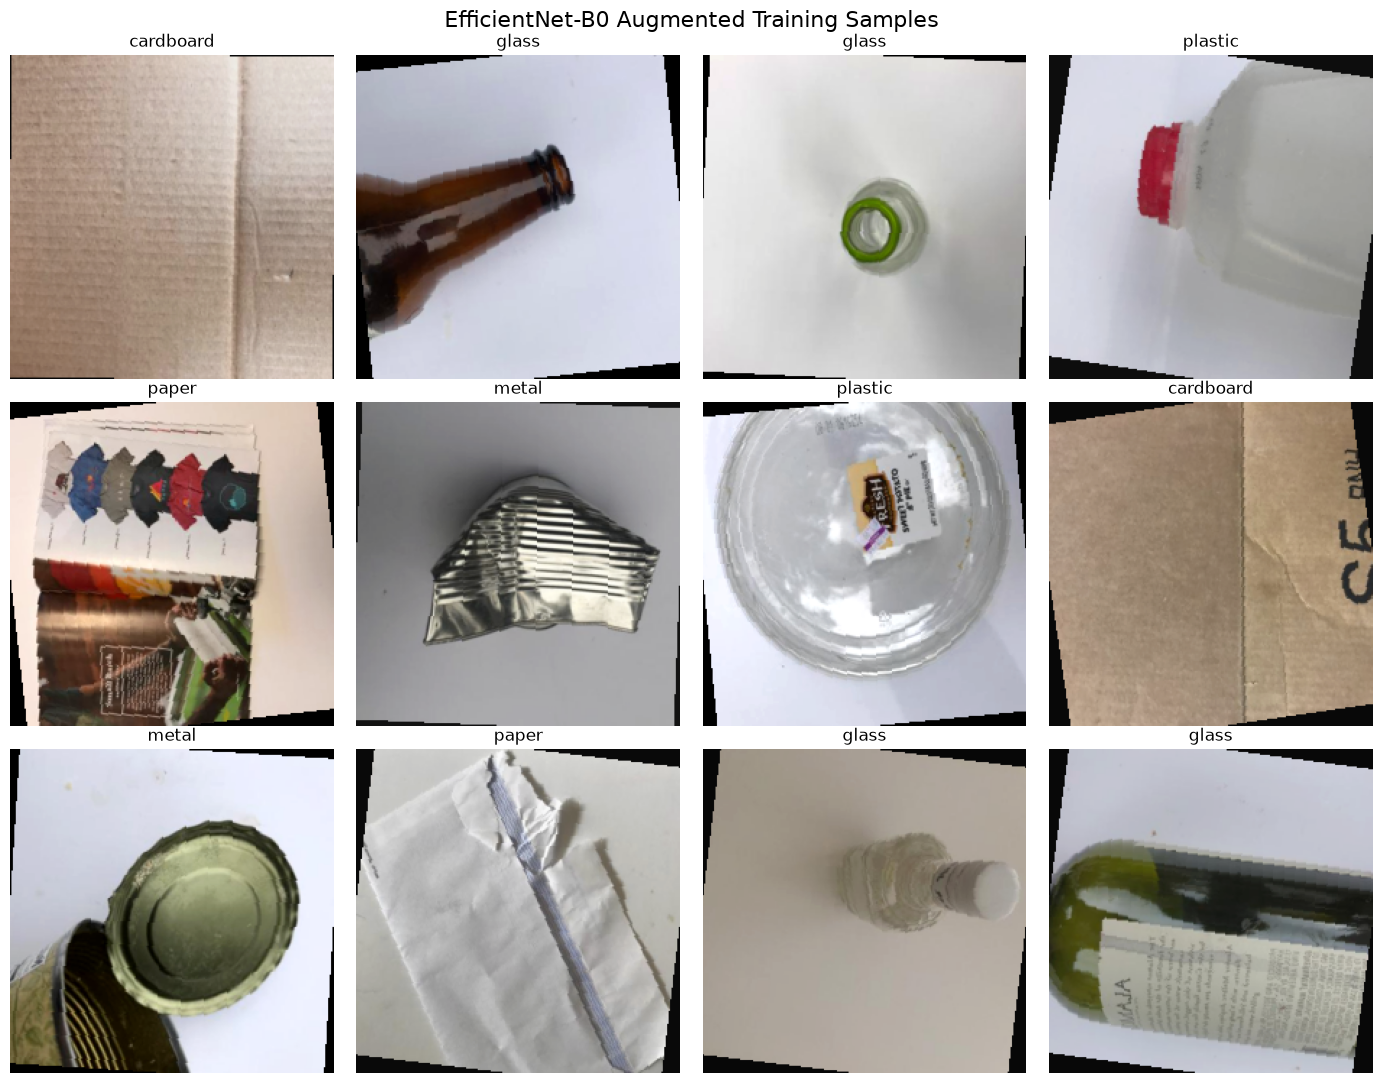

In [53]:
visualization_batch = next(
    iter(train_loader)
)

visualization_images = (
    visualization_batch["image"]
)

visualization_labels = (
    visualization_batch["label"]
)

NUMBER_OF_IMAGES_TO_DISPLAY = min(
    12,
    len(visualization_images),
)

figure, axes = plt.subplots(
    nrows=3,
    ncols=4,
    figsize=(14, 11),
)

axes = axes.flatten()

for image_index in range(
    NUMBER_OF_IMAGES_TO_DISPLAY
):
    image_tensor = denormalize_image(
        visualization_images[image_index]
    )

    image_for_display = (
        image_tensor
        .permute(1, 2, 0)
        .numpy()
    )

    label_index = int(
        visualization_labels[image_index]
    )

    axes[image_index].imshow(
        image_for_display
    )

    axes[image_index].set_title(
        index_to_class[label_index]
    )

    axes[image_index].axis("off")

for unused_axis in axes[
    NUMBER_OF_IMAGES_TO_DISPLAY:
]:
    unused_axis.axis("off")

plt.suptitle(
    "EfficientNet-B0 Augmented Training Samples",
    fontsize=16,
)

plt.tight_layout()
plt.show()

In [54]:
required_notebook_objects = [
    "train_loader",
    "validation_loader",
    "test_loader",
    "class_names",
    "class_to_index",
    "index_to_class",
    "class_weights",
    "DEVICE",
    "NUM_CLASSES",
]

missing_notebook_objects = [
    object_name
    for object_name in required_notebook_objects
    if object_name not in globals()
]

if missing_notebook_objects:
    raise RuntimeError(
        "The following required notebook objects are missing: "
        + ", ".join(missing_notebook_objects)
        + ". Run the earlier data-pipeline cells before continuing."
    )

print("All required training-pipeline objects are available.")
print(f"Number of classes : {NUM_CLASSES}")
print(f"Training batches  : {len(train_loader)}")
print(f"Validation batches: {len(validation_loader)}")
print(f"Test batches      : {len(test_loader)}")
print(f"Training device   : {DEVICE}")

All required training-pipeline objects are available.
Number of classes : 6
Training batches  : 111
Validation batches: 24
Test batches      : 24
Training device   : cpu


In [55]:
from torchvision.models import (
    EfficientNet_B0_Weights,
    efficientnet_b0,
)

EFFICIENTNET_WEIGHTS = (
    EfficientNet_B0_Weights.DEFAULT
)

print("Selected pretrained weights:")
print(EFFICIENTNET_WEIGHTS)

Selected pretrained weights:
EfficientNet_B0_Weights.IMAGENET1K_V1


In [56]:
from torchvision.models import (
    EfficientNet_B0_Weights,
    efficientnet_b0,
)

EFFICIENTNET_WEIGHTS = (
    EfficientNet_B0_Weights.DEFAULT
)

print("Selected pretrained weights:")
print(EFFICIENTNET_WEIGHTS)

Selected pretrained weights:
EfficientNet_B0_Weights.IMAGENET1K_V1


In [61]:
efficientnet_model = efficientnet_b0(
    weights=EFFICIENTNET_WEIGHTS
)

print("EfficientNet-B0 loaded successfully.")

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to C:\Users\Mudassar Iqbal Shah/.cache\torch\hub\checkpoints\efficientnet_b0_rwightman-7f5810bc.pth


100.0%


EfficientNet-B0 loaded successfully.


In [62]:
print(type(efficientnet_model))

<class 'torchvision.models.efficientnet.EfficientNet'>


In [63]:
print("Original EfficientNet-B0 classifier:")
print(efficientnet_model.classifier)

Original EfficientNet-B0 classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [64]:
if "efficientnet_model" not in globals():
    raise RuntimeError(
        "efficientnet_model has not been created. "
        "Run the EfficientNet-B0 model-construction cell first."
    )

print("EfficientNet-B0 model is available.")
print(efficientnet_model.classifier)

EfficientNet-B0 model is available.
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)


In [65]:
for parameter in efficientnet_model.features.parameters():
    parameter.requires_grad = False

print("EfficientNet-B0 feature extractor frozen.")

EfficientNet-B0 feature extractor frozen.


In [67]:
efficientnet_model.classifier = nn.Sequential(
    nn.Dropout(
        p=DROPOUT_RATE,
    ),
    nn.Linear(
        in_features=classifier_input_features,
        out_features=NUM_CLASSES,
    ),
)

In [68]:
print("Updated TrashNet classifier:")
print(efficientnet_model.classifier)

Updated TrashNet classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)


In [69]:
efficientnet_model = efficientnet_model.to(
    DEVICE
)

print(
    f"EfficientNet-B0 moved to device: "
    f"{DEVICE}"
)

EfficientNet-B0 moved to device: cpu


In [70]:
def count_model_parameters(
    model: nn.Module,
) -> dict:
    """
    Count total, trainable, and frozen model parameters.

    Parameters
    ----------
    model:
        PyTorch model to inspect.

    Returns
    -------
    dict
        Parameter-count summary.
    """
    total_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

    frozen_parameters = (
        total_parameters
        - trainable_parameters
    )

    return {
        "total_parameters": total_parameters,
        "trainable_parameters": trainable_parameters,
        "frozen_parameters": frozen_parameters,
    }


frozen_parameter_summary = count_model_parameters(
    efficientnet_model
)

parameter_summary_table = pd.DataFrame(
    [
        {
            "parameter_type": "Total",
            "count": frozen_parameter_summary[
                "total_parameters"
            ],
        },
        {
            "parameter_type": "Trainable",
            "count": frozen_parameter_summary[
                "trainable_parameters"
            ],
        },
        {
            "parameter_type": "Frozen",
            "count": frozen_parameter_summary[
                "frozen_parameters"
            ],
        },
    ]
)

parameter_summary_table[
    "formatted_count"
] = parameter_summary_table["count"].map(
    lambda value: f"{value:,}"
)

parameter_summary_table

,parameter_type,count,formatted_count
0,Total,4015234,"4,015,234"
1,Trainable,7686,"7,686"
2,Frozen,4007548,"4,007,548"


In [71]:
trainability_records = []

for parameter_name, parameter in (
    efficientnet_model.named_parameters()
):
    trainability_records.append(
        {
            "parameter_name": parameter_name,
            "trainable": parameter.requires_grad,
            "parameter_count": parameter.numel(),
        }
    )

trainability_table = pd.DataFrame(
    trainability_records
)

trainability_table.tail(15)

,parameter_name,trainable,parameter_count
198,features.7.0.block.1.0.weight,False,10368
199,features.7.0.block.1.1.weight,False,1152
200,features.7.0.block.1.1.bias,False,1152
201,features.7.0.block.2.fc1.weight,False,55296
202,features.7.0.block.2.fc1.bias,False,48
203,features.7.0.block.2.fc2.weight,False,55296
204,features.7.0.block.2.fc2.bias,False,1152
205,features.7.0.block.3.0.weight,False,368640
206,features.7.0.block.3.1.weight,False,320
207,features.7.0.block.3.1.bias,False,320


In [72]:
trainability_summary = (
    trainability_table
    .groupby("trainable")[
        "parameter_count"
    ]
    .sum()
    .rename(
        index={
            False: "Frozen",
            True: "Trainable",
        }
    )
)

trainability_summary

trainable
Frozen       4007548
Trainable       7686
Name: parameter_count, dtype: int64

In [73]:
efficientnet_model.eval()

smoke_test_batch = next(
    iter(train_loader)
)

smoke_test_images = (
    smoke_test_batch["image"]
    .to(DEVICE)
)

smoke_test_labels = (
    smoke_test_batch["label"]
    .to(DEVICE)
)

with torch.no_grad():
    smoke_test_logits = efficientnet_model(
        smoke_test_images
    )

print(
    "Input batch shape :",
    smoke_test_images.shape,
)

print(
    "Label batch shape :",
    smoke_test_labels.shape,
)

print(
    "Output shape      :",
    smoke_test_logits.shape,
)

Input batch shape : torch.Size([16, 3, 224, 224])
Label batch shape : torch.Size([16])
Output shape      : torch.Size([16, 6])


In [74]:
expected_output_shape = (
    smoke_test_images.shape[0],
    NUM_CLASSES,
)

if tuple(smoke_test_logits.shape) != (
    expected_output_shape
):
    raise ValueError(
        "Unexpected model output shape. "
        f"Expected {expected_output_shape}, "
        f"received {tuple(smoke_test_logits.shape)}."
    )

if not torch.isfinite(
    smoke_test_logits
).all():
    raise ValueError(
        "The smoke-test output contains "
        "NaN or infinite values."
    )

print(
    "EfficientNet-B0 forward-pass "
    "smoke test passed successfully."
)

EfficientNet-B0 forward-pass smoke test passed successfully.


In [75]:
smoke_test_probabilities = torch.softmax(
    smoke_test_logits,
    dim=1,
)

smoke_test_predictions = torch.argmax(
    smoke_test_probabilities,
    dim=1,
)

print(
    "First probability sum:",
    smoke_test_probabilities[0].sum().item(),
)

print(
    "First predicted class:",
    index_to_class[
        int(smoke_test_predictions[0])
    ],
)

print(
    "First confidence:",
    f"{smoke_test_probabilities[0].max().item():.4f}",
)

First probability sum: 1.0
First predicted class: metal
First confidence: 0.2714


In [76]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

print("Weighted cross-entropy loss configured.")
print("Class weights:")
print(class_weights)

Weighted cross-entropy loss configured.
Class weights:
tensor([1.0414, 0.8439, 1.0268, 0.7076, 0.8740, 3.0912])


In [77]:
smoke_test_loss = criterion(
    smoke_test_logits,
    smoke_test_labels,
)

print(
    "Smoke-test loss:",
    f"{smoke_test_loss.item():.4f}",
)

Smoke-test loss: 1.7817


In [78]:
if not torch.isfinite(
    smoke_test_loss
):
    raise ValueError(
        "The smoke-test loss is not finite."
    )

print(
    "Loss-function smoke test passed successfully."
)

Loss-function smoke test passed successfully.


In [79]:
trainable_parameters = [
    parameter
    for parameter in efficientnet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

print("Adam optimizer configured.")
print(f"Learning rate : {HEAD_LEARNING_RATE}")
print(f"Weight decay  : {WEIGHT_DECAY}")

Adam optimizer configured.
Learning rate : 0.001
Weight decay  : 0.0001


In [80]:
optimizer_parameter_count = sum(
    parameter.numel()
    for parameter_group in optimizer.param_groups
    for parameter in parameter_group["params"]
)

expected_trainable_parameter_count = (
    frozen_parameter_summary[
        "trainable_parameters"
    ]
)

print(
    "Optimizer parameters:",
    f"{optimizer_parameter_count:,}",
)

print(
    "Trainable model parameters:",
    f"{expected_trainable_parameter_count:,}",
)

if (
    optimizer_parameter_count
    != expected_trainable_parameter_count
):
    raise ValueError(
        "The optimizer parameter count does not "
        "match the trainable model parameter count."
    )

print(
    "Optimizer scope verified successfully."
)

Optimizer parameters: 7,686
Trainable model parameters: 7,686
Optimizer scope verified successfully.


In [81]:
scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "ReduceLROnPlateau scheduler configured."
)

ReduceLROnPlateau scheduler configured.


In [82]:
efficientnet_frozen_configuration = {
    "experiment_name": EXPERIMENT_NAME,
    "model_version": MODEL_VERSION,
    "architecture": "efficientnet_b0",
    "framework": "PyTorch",
    "torch_version": torch.__version__,
    "torchvision_version": (
        torchvision.__version__
    ),
    "pretrained_weights": str(
        EFFICIENTNET_WEIGHTS
    ),
    "number_of_classes": NUM_CLASSES,
    "class_names": class_names,
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "device": str(DEVICE),
    "training_stage": "frozen_feature_extraction",
    "maximum_epochs": HEAD_EPOCHS,
    "learning_rate": HEAD_LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "dropout_rate": DROPOUT_RATE,
    "parameter_summary": (
        frozen_parameter_summary
    ),
}

efficientnet_frozen_configuration

{'experiment_name': 'efficientnet_b0',
 'model_version': '1.0.0',
 'architecture': 'efficientnet_b0',
 'framework': 'PyTorch',
 'torch_version': '2.13.0+cpu',
 'torchvision_version': '0.28.0+cpu',
 'pretrained_weights': 'EfficientNet_B0_Weights.IMAGENET1K_V1',
 'number_of_classes': 6,
 'class_names': ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash'],
 'image_size': [224, 224],
 'batch_size': 16,
 'device': 'cpu',
 'training_stage': 'frozen_feature_extraction',
 'maximum_epochs': 10,
 'learning_rate': 0.001,
 'weight_decay': 0.0001,
 'dropout_rate': 0.3,
 'parameter_summary': {'total_parameters': 4015234,
  'trainable_parameters': 7686,
  'frozen_parameters': 4007548}}

In [83]:
frozen_configuration_path = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_frozen_configuration.json"
)

with open(
    frozen_configuration_path,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        efficientnet_frozen_configuration,
        configuration_file,
        indent=4,
    )

print(
    "Frozen-stage configuration saved to:"
)

print(
    frozen_configuration_path.resolve()
)

Frozen-stage configuration saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_frozen_configuration.json


In [84]:
required_training_objects = [
    "efficientnet_model",
    "train_loader",
    "validation_loader",
    "test_loader",
    "criterion",
    "optimizer",
    "scheduler",
    "DEVICE",
    "HEAD_EPOCHS",
    "FROZEN_CHECKPOINT_PATH",
    "class_names",
    "index_to_class",
    "NUM_CLASSES",
]

missing_training_objects = [
    object_name
    for object_name in required_training_objects
    if object_name not in globals()
]

if missing_training_objects:
    raise RuntimeError(
        "The following required objects are missing: "
        + ", ".join(missing_training_objects)
        + ". Run the earlier notebook cells before continuing."
    )

print("All frozen-training prerequisites are available.")
print(f"Device: {DEVICE}")
print(f"Maximum frozen-stage epochs: {HEAD_EPOCHS}")
print(f"Checkpoint path: {FROZEN_CHECKPOINT_PATH}")

All frozen-training prerequisites are available.
Device: cpu
Maximum frozen-stage epochs: 10
Checkpoint path: ..\models\efficientnet_b0_frozen_best.pt


In [85]:
def calculate_accuracy(
    logits: torch.Tensor,
    labels: torch.Tensor,
) -> int:
    """
    Count the number of correct predictions in one batch.

    Parameters
    ----------
    logits:
        Raw model outputs with shape:
        (batch_size, number_of_classes)

    labels:
        Correct integer class labels with shape:
        (batch_size,)

    Returns
    -------
    int
        Number of correctly classified images.
    """
    predicted_labels = torch.argmax(
        logits,
        dim=1,
    )

    correct_predictions = (
        predicted_labels == labels
    ).sum().item()

    return int(correct_predictions)

In [86]:
def train_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict:
    """
    Train a PyTorch model for one complete epoch.

    Parameters
    ----------
    model:
        Model being trained.

    data_loader:
        Training DataLoader.

    loss_function:
        Classification loss function.

    optimizer:
        Optimizer used to update trainable parameters.

    device:
        CPU or CUDA device.

    Returns
    -------
    dict
        Average loss, accuracy, correct predictions,
        and processed sample count.
    """
    model.train()

    running_loss = 0.0
    running_correct_predictions = 0
    running_sample_count = 0

    for batch in data_loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            labels,
        )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        running_correct_predictions += (
            calculate_accuracy(
                logits,
                labels,
            )
        )

        running_sample_count += batch_size

    if running_sample_count == 0:
        raise RuntimeError(
            "The training DataLoader returned no samples."
        )

    average_loss = (
        running_loss / running_sample_count
    )

    accuracy = (
        running_correct_predictions
        / running_sample_count
    )

    return {
        "loss": float(average_loss),
        "accuracy": float(accuracy),
        "correct_predictions": int(
            running_correct_predictions
        ),
        "sample_count": int(
            running_sample_count
        ),
    }

In [87]:
def validate_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate a PyTorch model for one complete validation epoch.

    Parameters
    ----------
    model:
        Model being evaluated.

    data_loader:
        Validation DataLoader.

    loss_function:
        Classification loss function.

    device:
        CPU or CUDA device.

    Returns
    -------
    dict
        Average validation loss, accuracy, correct
        predictions, and processed sample count.
    """
    model.eval()

    running_loss = 0.0
    running_correct_predictions = 0
    running_sample_count = 0

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            running_correct_predictions += (
                calculate_accuracy(
                    logits,
                    labels,
                )
            )

            running_sample_count += batch_size

    if running_sample_count == 0:
        raise RuntimeError(
            "The validation DataLoader returned no samples."
        )

    average_loss = (
        running_loss / running_sample_count
    )

    accuracy = (
        running_correct_predictions
        / running_sample_count
    )

    return {
        "loss": float(average_loss),
        "accuracy": float(accuracy),
        "correct_predictions": int(
            running_correct_predictions
        ),
        "sample_count": int(
            running_sample_count
        ),
    }

In [88]:
validation_smoke_test = validate_one_epoch(
    model=efficientnet_model,
    data_loader=validation_loader,
    loss_function=criterion,
    device=DEVICE,
)

print("Validation smoke-test results:")
print(
    f"Loss     : "
    f"{validation_smoke_test['loss']:.4f}"
)
print(
    f"Accuracy : "
    f"{validation_smoke_test['accuracy']:.4f}"
)
print(
    f"Samples  : "
    f"{validation_smoke_test['sample_count']}"
)

Validation smoke-test results:
Loss     : 1.8561
Accuracy : 0.1190
Samples  : 378


In [ ]:
def save_training_checkpoint(
    checkpoint_path: Path,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    validation_loss: float,
    validation_accuracy: float,
    class_names: list,
    class_to_index: dict,
    model_version: str,
    image_size: tuple,
    training_stage: str,
) -> None:
    """
    Save model weights and training metadata.

    Parameters
    ----------
    checkpoint_path:
        Destination path for the checkpoint.

    model:
        Trained PyTorch model.

    optimizer:
        Optimizer used during training.

    epoch:
        Completed epoch number.

    validation_loss:
        Validation loss achieved by the checkpoint.

    validation_accuracy:
        Validation accuracy achieved by the checkpoint.

    class_names:
        Ordered class-name list.

    class_to_index:
        String-to-integer class mapping.

    model_version:
        Version identifier for the model.

    image_size:
        Expected input image dimensions.

    training_stage:
        Description of the training stage.
    """
    checkpoint_path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    checkpoint = {
        "architecture": "efficientnet_b0",
        "model_version": model_version,
        "training_stage": training_stage,
        "epoch": int(epoch),
        "model_state_dict": (
            model.state_dict()
        ),
        "optimizer_state_dict": (
            optimizer.state_dict()
        ),
        "validation_loss": float(
            validation_loss
        ),
        "validation_accuracy": float(
            validation_accuracy
        ),
        "class_names": list(class_names),
        "class_to_index": dict(
            class_to_index
        ),
        "number_of_classes": len(
            class_names
        ),
        "image_size": list(image_size),
        "saved_at": (
            datetime.now().isoformat()
        ),
        "pytorch_version": (
            torch.__version__
        ),
        "torchvision_version": (
            torchvision.__version__
        ),
    }

    torch.save(
        checkpoint,
        checkpoint_path,
    )

In [90]:
EARLY_STOPPING_PATIENCE = 5
MINIMUM_IMPROVEMENT = 1e-4

print(
    f"Early stopping patience: "
    f"{EARLY_STOPPING_PATIENCE} epochs"
)

print(
    f"Minimum improvement: "
    f"{MINIMUM_IMPROVEMENT}"
)

Early stopping patience: 5 epochs
Minimum improvement: 0.0001


In [91]:
def train_frozen_model(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: torch.device,
    maximum_epochs: int,
    checkpoint_path: Path,
    class_names: list,
    class_to_index: dict,
    model_version: str,
    image_size: tuple,
    early_stopping_patience: int = 5,
    minimum_improvement: float = 1e-4,
) -> pd.DataFrame:
    """
    Train the frozen EfficientNet-B0 classifier.

    Returns
    -------
    pandas.DataFrame
        Epoch-level training history.
    """
    training_history = []

    best_validation_loss = float("inf")
    non_improving_epoch_count = 0

    training_start_time = time.perf_counter()

    for epoch_index in range(
        maximum_epochs
    ):
        epoch_number = epoch_index + 1

        epoch_start_time = (
            time.perf_counter()
        )

        current_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        training_metrics = train_one_epoch(
            model=model,
            data_loader=train_loader,
            loss_function=loss_function,
            optimizer=optimizer,
            device=device,
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=validation_loader,
                loss_function=loss_function,
                device=device,
            )
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        validation_improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - minimum_improvement
            )
        )

        if validation_improved:
            best_validation_loss = (
                validation_metrics["loss"]
            )

            non_improving_epoch_count = 0

            save_training_checkpoint(
                checkpoint_path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch_number,
                validation_loss=(
                    validation_metrics["loss"]
                ),
                validation_accuracy=(
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                class_names=class_names,
                class_to_index=class_to_index,
                model_version=model_version,
                image_size=image_size,
                training_stage=(
                    "frozen_feature_extraction"
                ),
            )

            checkpoint_status = (
                "Best checkpoint saved"
            )

        else:
            non_improving_epoch_count += 1

            checkpoint_status = (
                "No validation improvement"
            )

        epoch_record = {
            "epoch": epoch_number,
            "learning_rate": (
                current_learning_rate
            ),
            "train_loss": (
                training_metrics["loss"]
            ),
            "train_accuracy": (
                training_metrics["accuracy"]
            ),
            "validation_loss": (
                validation_metrics["loss"]
            ),
            "validation_accuracy": (
                validation_metrics["accuracy"]
            ),
            "epoch_duration_seconds": (
                epoch_duration_seconds
            ),
            "checkpoint_saved": bool(
                validation_improved
            ),
        }

        training_history.append(
            epoch_record
        )

        print("=" * 80)

        print(
            f"Epoch "
            f"{epoch_number}/{maximum_epochs}"
        )

        print(
            f"Learning rate       : "
            f"{current_learning_rate:.8f}"
        )

        print(
            f"Training loss       : "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"Training accuracy   : "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation loss     : "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy : "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Epoch duration      : "
            f"{epoch_duration_seconds:.2f} seconds"
        )

        print(
            f"Checkpoint status   : "
            f"{checkpoint_status}"
        )

        print(
            f"Early-stop counter  : "
            f"{non_improving_epoch_count}/"
            f"{early_stopping_patience}"
        )

        if (
            non_improving_epoch_count
            >= early_stopping_patience
        ):
            print("=" * 80)
            print(
                "Early stopping activated."
            )
            break

    total_training_duration = (
        time.perf_counter()
        - training_start_time
    )

    print("=" * 80)
    print(
        "Frozen feature-extraction "
        "training completed."
    )
    print(
        f"Total training duration: "
        f"{total_training_duration / 60:.2f} minutes"
    )
    print(
        f"Best validation loss: "
        f"{best_validation_loss:.4f}"
    )

    history_dataframe = pd.DataFrame(
        training_history
    )

    return history_dataframe

In [92]:
SMOKE_TEST_CHECKPOINT_PATH = (
    MODEL_DIRECTORY
    / "efficientnet_b0_training_smoke_test.pt"
)

In [93]:
smoke_test_history = train_frozen_model(
    model=efficientnet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    maximum_epochs=1,
    checkpoint_path=(
        SMOKE_TEST_CHECKPOINT_PATH
    ),
    class_names=class_names,
    class_to_index=class_to_index,
    model_version=MODEL_VERSION,
    image_size=IMAGE_SIZE,
    early_stopping_patience=1,
    minimum_improvement=(
        MINIMUM_IMPROVEMENT
    ),
)

smoke_test_history

Epoch 1/1
Learning rate       : 0.00100000
Training loss       : 1.2852
Training accuracy   : 0.5880
Validation loss     : 0.9882
Validation accuracy : 0.6958
Epoch duration      : 181.84 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/1
Frozen feature-extraction training completed.
Total training duration: 3.03 minutes
Best validation loss: 0.9882


,epoch,learning_rate,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.001,1.285168,0.587968,0.988236,0.695767,181.844311,True


In [94]:
set_random_seed(SEED)

efficientnet_model = efficientnet_b0(
    weights=EFFICIENTNET_WEIGHTS
)

for parameter in (
    efficientnet_model.features.parameters()
):
    parameter.requires_grad = False

classifier_input_features = (
    efficientnet_model.classifier[1]
    .in_features
)

efficientnet_model.classifier = (
    nn.Sequential(
        nn.Dropout(
            p=DROPOUT_RATE
        ),
        nn.Linear(
            in_features=(
                classifier_input_features
            ),
            out_features=NUM_CLASSES,
        ),
    )
)

efficientnet_model = (
    efficientnet_model.to(DEVICE)
)

class_weights = class_weights.to(DEVICE)

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)

trainable_parameters = [
    parameter
    for parameter
    in efficientnet_model.parameters()
    if parameter.requires_grad
]

optimizer = Adam(
    params=trainable_parameters,
    lr=HEAD_LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = ReduceLROnPlateau(
    optimizer=optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "EfficientNet-B0 was reinitialized "
    "for the official frozen-stage experiment."
)

EfficientNet-B0 was reinitialized for the official frozen-stage experiment.


In [95]:
frozen_training_history = train_frozen_model(
    model=efficientnet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=DEVICE,
    maximum_epochs=HEAD_EPOCHS,
    checkpoint_path=(
        FROZEN_CHECKPOINT_PATH
    ),
    class_names=class_names,
    class_to_index=class_to_index,
    model_version=MODEL_VERSION,
    image_size=IMAGE_SIZE,
    early_stopping_patience=(
        EARLY_STOPPING_PATIENCE
    ),
    minimum_improvement=(
        MINIMUM_IMPROVEMENT
    ),
)

Epoch 1/10
Learning rate       : 0.00100000
Training loss       : 1.3188
Training accuracy   : 0.5562
Validation loss     : 0.9776
Validation accuracy : 0.7143
Epoch duration      : 177.44 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Epoch 2/10
Learning rate       : 0.00100000
Training loss       : 0.9211
Training accuracy   : 0.7213
Validation loss     : 0.8589
Validation accuracy : 0.7381
Epoch duration      : 168.46 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Epoch 3/10
Learning rate       : 0.00100000
Training loss       : 0.8124
Training accuracy   : 0.7401
Validation loss     : 0.7765
Validation accuracy : 0.7407
Epoch duration      : 189.16 seconds
Checkpoint status   : Best checkpoint saved
Early-stop counter  : 0/5
Epoch 4/10
Learning rate       : 0.00100000
Training loss       : 0.7171
Training accuracy   : 0.7656
Validation loss     : 0.7445
Validation accuracy : 0.7460
Epoch duration      : 172.83 seconds
Ch

In [96]:
FROZEN_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "efficientnet_b0_frozen_history.csv"
)

frozen_training_history.to_csv(
    FROZEN_HISTORY_PATH,
    index=False,
)

print(
    "Frozen-stage history saved to:"
)

print(
    FROZEN_HISTORY_PATH.resolve()
)

Frozen-stage history saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\efficientnet_b0_frozen_history.csv


In [97]:
if not FROZEN_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The expected frozen-stage checkpoint "
        "was not created."
    )

checkpoint_size_mb = (
    FROZEN_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    "Frozen checkpoint created successfully."
)

print(
    f"Checkpoint size: "
    f"{checkpoint_size_mb:.2f} MB"
)

Frozen checkpoint created successfully.
Checkpoint size: 15.67 MB


In [98]:
def plot_frozen_learning_curves(
    history_dataframe: pd.DataFrame,
    figures_directory: Path,
) -> None:
    """
    Plot and save frozen-stage accuracy and loss curves.
    """
    required_columns = {
        "epoch",
        "train_loss",
        "validation_loss",
        "train_accuracy",
        "validation_accuracy",
    }

    missing_columns = (
        required_columns
        - set(history_dataframe.columns)
    )

    if missing_columns:
        raise ValueError(
            "Training history is missing columns: "
            + ", ".join(
                sorted(missing_columns)
            )
        )

    figures_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "train_accuracy"
        ],
        marker="o",
        label="Training Accuracy",
    )

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "validation_accuracy"
        ],
        marker="o",
        label="Validation Accuracy",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        "EfficientNet-B0 Frozen-Stage Accuracy"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    accuracy_figure_path = (
        figures_directory
        / "efficientnet_b0_frozen_accuracy.png"
    )

    plt.savefig(
        accuracy_figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(figsize=(9, 6))

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe["train_loss"],
        marker="o",
        label="Training Loss",
    )

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "validation_loss"
        ],
        marker="o",
        label="Validation Loss",
    )

    plt.xlabel("Epoch")
    plt.ylabel("Weighted Cross-Entropy Loss")
    plt.title(
        "EfficientNet-B0 Frozen-Stage Loss"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    loss_figure_path = (
        figures_directory
        / "efficientnet_b0_frozen_loss.png"
    )

    plt.savefig(
        loss_figure_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        "Accuracy curve saved to:"
    )
    print(
        accuracy_figure_path.resolve()
    )

    print(
        "\nLoss curve saved to:"
    )
    print(
        loss_figure_path.resolve()
    )

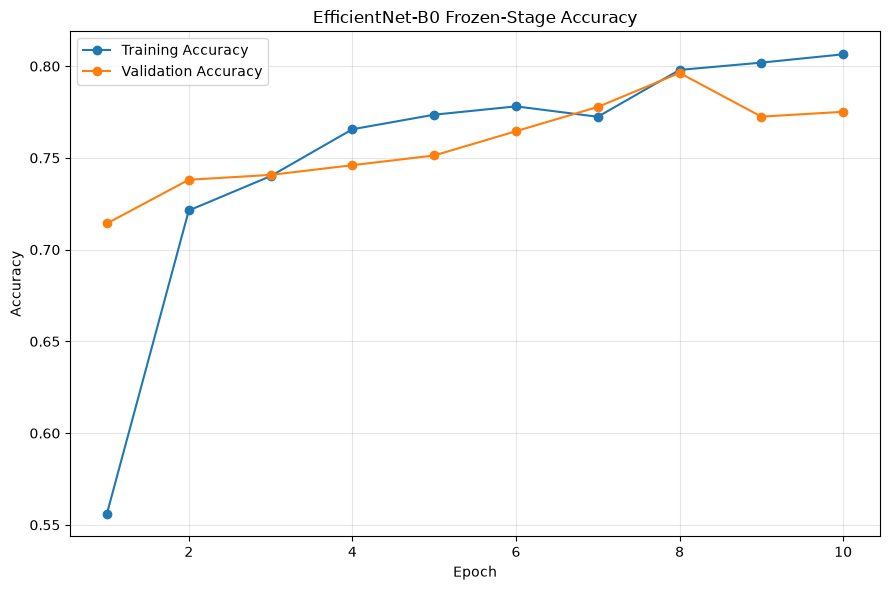

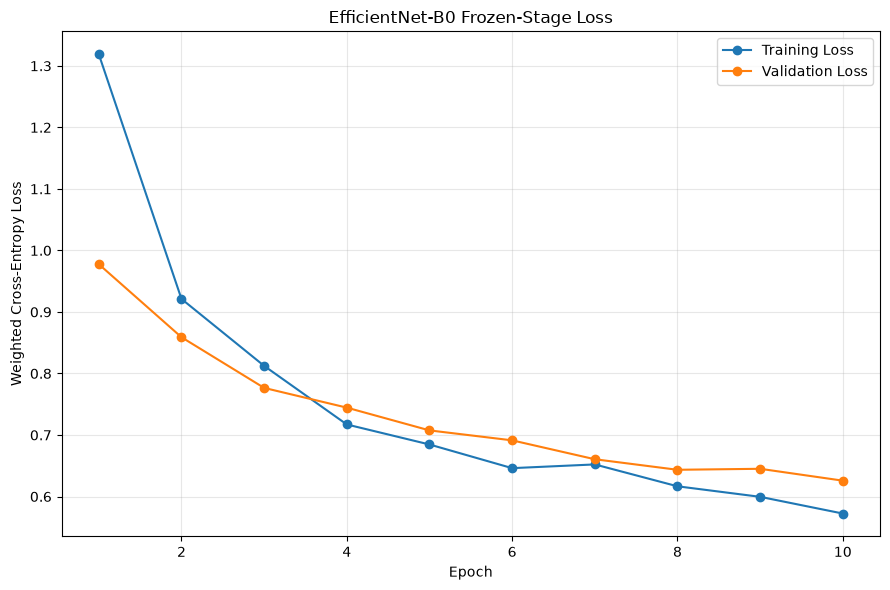

Accuracy curve saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\figures\efficientnet_b0_frozen_accuracy.png

Loss curve saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\figures\efficientnet_b0_frozen_loss.png


In [99]:
plot_frozen_learning_curves(
    history_dataframe=(
        frozen_training_history
    ),
    figures_directory=(
        FIGURES_DIRECTORY
    ),
)

In [100]:
best_frozen_row_index = (
    frozen_training_history[
        "validation_loss"
    ].idxmin()
)

best_frozen_record = (
    frozen_training_history.loc[
        best_frozen_row_index
    ]
)

best_frozen_epoch = int(
    best_frozen_record["epoch"]
)

best_frozen_validation_loss = float(
    best_frozen_record[
        "validation_loss"
    ]
)

best_frozen_validation_accuracy = float(
    best_frozen_record[
        "validation_accuracy"
    ]
)

print(
    f"Best frozen epoch: "
    f"{best_frozen_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_frozen_validation_loss:.4f}"
)

print(
    f"Validation accuracy at best epoch: "
    f"{best_frozen_validation_accuracy:.4f}"
)

Best frozen epoch: 10
Best validation loss: 0.6258
Validation accuracy at best epoch: 0.7751


In [101]:
frozen_checkpoint = torch.load(
    FROZEN_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

checkpoint_summary = {
    "architecture": frozen_checkpoint[
        "architecture"
    ],
    "model_version": frozen_checkpoint[
        "model_version"
    ],
    "training_stage": frozen_checkpoint[
        "training_stage"
    ],
    "epoch": frozen_checkpoint[
        "epoch"
    ],
    "validation_loss": frozen_checkpoint[
        "validation_loss"
    ],
    "validation_accuracy": (
        frozen_checkpoint[
            "validation_accuracy"
        ]
    ),
    "number_of_classes": (
        frozen_checkpoint[
            "number_of_classes"
        ]
    ),
    "image_size": frozen_checkpoint[
        "image_size"
    ],
    "saved_at": frozen_checkpoint[
        "saved_at"
    ],
}

checkpoint_summary

{'architecture': 'efficientnet_b0',
 'model_version': '1.0.0',
 'training_stage': 'frozen_feature_extraction',
 'epoch': 10,
 'validation_loss': 0.6257856652219459,
 'validation_accuracy': 0.7751322751322751,
 'number_of_classes': 6,
 'image_size': [224, 224],
 'saved_at': '2026-08-02T13:28:28.022796'}

In [102]:
efficientnet_model.load_state_dict(
    frozen_checkpoint[
        "model_state_dict"
    ]
)

efficientnet_model = (
    efficientnet_model.to(DEVICE)
)

efficientnet_model.eval()

print(
    "Best frozen-stage model weights "
    "restored successfully."
)

Best frozen-stage model weights restored successfully.


In [103]:
best_frozen_validation_metrics = (
    validate_one_epoch(
        model=efficientnet_model,
        data_loader=validation_loader,
        loss_function=criterion,
        device=DEVICE,
    )
)

print(
    "Best frozen model validation results:"
)

print(
    f"Loss     : "
    f"{best_frozen_validation_metrics['loss']:.4f}"
)

print(
    f"Accuracy : "
    f"{best_frozen_validation_metrics['accuracy']:.4f}"
)

print(
    f"Samples  : "
    f"{best_frozen_validation_metrics['sample_count']}"
)

Best frozen model validation results:
Loss     : 0.6258
Accuracy : 0.7751
Samples  : 378


##  Controlled Fine-Tuning

The frozen feature-extraction stage trained only the newly added TrashNet
classification head.

The next stage performs controlled fine-tuning by allowing selected upper
EfficientNet-B0 feature layers to adapt to waste-classification images.

Fine-tuning is performed conservatively because TrashNet is much smaller than
ImageNet. Unfreezing the entire network with a large learning rate could destroy
useful pretrained visual representations, a problem known as catastrophic
forgetting.

The fine-tuning strategy is therefore:

1. Restore the best frozen-stage checkpoint.
2. Keep the lower EfficientNet-B0 feature blocks frozen.
3. Unfreeze only the final feature blocks.
4. Keep Batch Normalization layers frozen.
5. Use a very small learning rate for pretrained backbone parameters.
6. Use a slightly larger learning rate for the already trained classifier.
7. Monitor validation loss for checkpointing and early stopping.
8. Keep the test set completely isolated.

In [104]:
required_fine_tuning_objects = [
    "efficientnet_model",
    "train_loader",
    "validation_loader",
    "criterion",
    "DEVICE",
    "FROZEN_CHECKPOINT_PATH",
    "FINE_TUNED_CHECKPOINT_PATH",
    "FINE_TUNE_EPOCHS",
    "class_names",
    "class_to_index",
    "NUM_CLASSES",
    "IMAGE_SIZE",
    "MODEL_VERSION",
]

missing_fine_tuning_objects = [
    object_name
    for object_name in required_fine_tuning_objects
    if object_name not in globals()
]

if missing_fine_tuning_objects:
    raise RuntimeError(
        "The following required fine-tuning objects are missing: "
        + ", ".join(missing_fine_tuning_objects)
        + ". Run the previous notebook cells before continuing."
    )

if not FROZEN_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The best frozen-stage checkpoint was not found at: "
        f"{FROZEN_CHECKPOINT_PATH}"
    )

print("All fine-tuning prerequisites are available.")
print(f"Frozen checkpoint : {FROZEN_CHECKPOINT_PATH}")
print(f"Fine-tuned output : {FINE_TUNED_CHECKPOINT_PATH}")
print(f"Device            : {DEVICE}")

All fine-tuning prerequisites are available.
Frozen checkpoint : ..\models\efficientnet_b0_frozen_best.pt
Fine-tuned output : ..\models\efficientnet_b0_finetuned_best.pt
Device            : cpu


In [105]:
frozen_checkpoint = torch.load(
    FROZEN_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

efficientnet_model.load_state_dict(
    frozen_checkpoint["model_state_dict"]
)

efficientnet_model = efficientnet_model.to(
    DEVICE
)

print("Best frozen-stage weights restored.")
print(
    "Frozen checkpoint epoch:",
    frozen_checkpoint["epoch"],
)
print(
    "Frozen validation loss:",
    f"{frozen_checkpoint['validation_loss']:.4f}",
)
print(
    "Frozen validation accuracy:",
    f"{frozen_checkpoint['validation_accuracy']:.4f}",
)

Best frozen-stage weights restored.
Frozen checkpoint epoch: 10
Frozen validation loss: 0.6258
Frozen validation accuracy: 0.7751


In [106]:
frozen_best_epoch = int(
    frozen_checkpoint["epoch"]
)

frozen_best_validation_loss = float(
    frozen_checkpoint["validation_loss"]
)

frozen_best_validation_accuracy = float(
    frozen_checkpoint["validation_accuracy"]
)

In [107]:
print("EfficientNet-B0 feature blocks")
print("=" * 80)

for block_index, block in enumerate(
    efficientnet_model.features
):
    block_parameter_count = sum(
        parameter.numel()
        for parameter in block.parameters()
    )

    print(
        f"Block {block_index}: "
        f"{block.__class__.__name__} "
        f"({block_parameter_count:,} parameters)"
    )

EfficientNet-B0 feature blocks
Block 0: Conv2dNormActivation (928 parameters)
Block 1: Sequential (1,448 parameters)
Block 2: Sequential (16,714 parameters)
Block 3: Sequential (46,640 parameters)
Block 4: Sequential (242,930 parameters)
Block 5: Sequential (543,148 parameters)
Block 6: Sequential (2,026,348 parameters)
Block 7: Sequential (717,232 parameters)
Block 8: Conv2dNormActivation (412,160 parameters)


In [108]:
FINE_TUNE_LAST_N_BLOCKS = 2

number_of_feature_blocks = len(
    efficientnet_model.features
)

if (
    FINE_TUNE_LAST_N_BLOCKS <= 0
    or FINE_TUNE_LAST_N_BLOCKS
    > number_of_feature_blocks
):
    raise ValueError(
        "FINE_TUNE_LAST_N_BLOCKS must be between "
        f"1 and {number_of_feature_blocks}."
    )

first_trainable_block_index = (
    number_of_feature_blocks
    - FINE_TUNE_LAST_N_BLOCKS
)

print(
    f"Total feature blocks       : "
    f"{number_of_feature_blocks}"
)

print(
    f"Fine-tuned feature blocks  : "
    f"{FINE_TUNE_LAST_N_BLOCKS}"
)

print(
    f"First trainable block index: "
    f"{first_trainable_block_index}"
)

Total feature blocks       : 9
Fine-tuned feature blocks  : 2
First trainable block index: 7


In [109]:
for parameter in efficientnet_model.parameters():
    parameter.requires_grad = False

print("All model parameters temporarily frozen.")

All model parameters temporarily frozen.


In [110]:
for parameter in (
    efficientnet_model.classifier.parameters()
):
    parameter.requires_grad = True

print("TrashNet classifier marked as trainable.")

TrashNet classifier marked as trainable.


In [111]:
for block in efficientnet_model.features[
    first_trainable_block_index:
]:
    for parameter in block.parameters():
        parameter.requires_grad = True

print(
    f"Feature blocks "
    f"{first_trainable_block_index} to "
    f"{number_of_feature_blocks - 1} "
    "marked as trainable."
)

Feature blocks 7 to 8 marked as trainable.


In [112]:
def freeze_batch_normalization_parameters(
    model: nn.Module,
) -> int:
    """
    Freeze all Batch Normalization parameters.

    Returns
    -------
    int
        Number of Batch Normalization modules found.
    """
    batch_norm_module_count = 0

    for module in model.modules():
        if isinstance(
            module,
            (
                nn.BatchNorm1d,
                nn.BatchNorm2d,
                nn.BatchNorm3d,
            ),
        ):
            batch_norm_module_count += 1

            for parameter in module.parameters():
                parameter.requires_grad = False

    return batch_norm_module_count


batch_norm_module_count = (
    freeze_batch_normalization_parameters(
        efficientnet_model
    )
)

print(
    f"Frozen Batch Normalization modules: "
    f"{batch_norm_module_count}"
)

Frozen Batch Normalization modules: 49


In [113]:
def set_batch_normalization_to_evaluation(
    model: nn.Module,
) -> None:
    """
    Keep Batch Normalization modules in evaluation mode.
    """
    for module in model.modules():
        if isinstance(
            module,
            (
                nn.BatchNorm1d,
                nn.BatchNorm2d,
                nn.BatchNorm3d,
            ),
        ):
            module.eval()

In [115]:
feature_block_trainability = []

for block_index, block in enumerate(
    efficientnet_model.features
):
    total_parameters = sum(
        parameter.numel()
        for parameter in block.parameters()
    )

    trainable_parameters = sum(
        parameter.numel()
        for parameter in block.parameters()
        if parameter.requires_grad
    )

    feature_block_trainability.append(
        {
            "block_index": block_index,
            "total_parameters": total_parameters,
            "trainable_parameters": (
                trainable_parameters
            ),
            "frozen_parameters": (
                total_parameters
                - trainable_parameters
            ),
            "contains_trainable_parameters": (
                trainable_parameters > 0
            ),
        }
    )

feature_block_trainability_table = (
    pd.DataFrame(
        feature_block_trainability
    )
)

feature_block_trainability_table

,block_index,total_parameters,trainable_parameters,frozen_parameters,contains_trainable_parameters
0,0,928,0,928,False
1,1,1448,0,1448,False
2,2,16714,0,16714,False
3,3,46640,0,46640,False
4,4,242930,0,242930,False
5,5,543148,0,543148,False
6,6,2026348,0,2026348,False
7,7,717232,711984,5248,True
8,8,412160,409600,2560,True


In [116]:
classifier_trainable_parameters = sum(
    parameter.numel()
    for parameter
    in efficientnet_model.classifier.parameters()
    if parameter.requires_grad
)

classifier_total_parameters = sum(
    parameter.numel()
    for parameter
    in efficientnet_model.classifier.parameters()
)

print(
    "Classifier trainable parameters:",
    f"{classifier_trainable_parameters:,}",
)

print(
    "Classifier total parameters:",
    f"{classifier_total_parameters:,}",
)

Classifier trainable parameters: 7,686
Classifier total parameters: 7,686


In [117]:
fine_tuning_parameter_summary = (
    count_model_parameters(
        efficientnet_model
    )
)

fine_tuning_parameter_table = pd.DataFrame(
    [
        {
            "parameter_type": "Total",
            "count": (
                fine_tuning_parameter_summary[
                    "total_parameters"
                ]
            ),
        },
        {
            "parameter_type": "Trainable",
            "count": (
                fine_tuning_parameter_summary[
                    "trainable_parameters"
                ]
            ),
        },
        {
            "parameter_type": "Frozen",
            "count": (
                fine_tuning_parameter_summary[
                    "frozen_parameters"
                ]
            ),
        },
    ]
)

fine_tuning_parameter_table[
    "formatted_count"
] = fine_tuning_parameter_table[
    "count"
].map(
    lambda value: f"{value:,}"
)

fine_tuning_parameter_table

,parameter_type,count,formatted_count
0,Total,4015234,"4,015,234"
1,Trainable,1129270,"1,129,270"
2,Frozen,2885964,"2,885,964"


In [118]:
BACKBONE_FINE_TUNE_LEARNING_RATE = 1e-5
CLASSIFIER_FINE_TUNE_LEARNING_RATE = 1e-4

print(
    "Backbone fine-tuning learning rate:",
    BACKBONE_FINE_TUNE_LEARNING_RATE,
)

print(
    "Classifier fine-tuning learning rate:",
    CLASSIFIER_FINE_TUNE_LEARNING_RATE,
)

Backbone fine-tuning learning rate: 1e-05
Classifier fine-tuning learning rate: 0.0001


In [119]:
trainable_backbone_parameters = [
    parameter
    for parameter
    in efficientnet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in efficientnet_model.classifier.parameters()
    if parameter.requires_grad
]

print(
    "Trainable backbone tensors:",
    len(trainable_backbone_parameters),
)

print(
    "Trainable classifier tensors:",
    len(trainable_classifier_parameters),
)

Trainable backbone tensors: 8
Trainable classifier tensors: 2


In [120]:
fine_tuning_optimizer = Adam(
    [
        {
            "params": trainable_backbone_parameters,
            "lr": BACKBONE_FINE_TUNE_LEARNING_RATE,
            "name": "backbone",
        },
        {
            "params": trainable_classifier_parameters,
            "lr": CLASSIFIER_FINE_TUNE_LEARNING_RATE,
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

print("Fine-tuning optimizer configured.")

Fine-tuning optimizer configured.


In [121]:
for group_index, parameter_group in enumerate(
    fine_tuning_optimizer.param_groups
):
    parameter_count = sum(
        parameter.numel()
        for parameter in parameter_group["params"]
    )

    print(
        f"Group {group_index}: "
        f"{parameter_group.get('name', 'unnamed')}"
    )

    print(
        f"  Learning rate : "
        f"{parameter_group['lr']}"
    )

    print(
        f"  Parameters    : "
        f"{parameter_count:,}"
    )

Group 0: backbone
  Learning rate : 1e-05
  Parameters    : 1,121,584
Group 1: classifier
  Learning rate : 0.0001
  Parameters    : 7,686


In [122]:
fine_tuning_scheduler = ReduceLROnPlateau(
    optimizer=fine_tuning_optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "Fine-tuning ReduceLROnPlateau "
    "scheduler configured."
)

Fine-tuning ReduceLROnPlateau scheduler configured.


In [123]:
class_weights = class_weights.to(
    DEVICE
)

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights
    )
)

print(
    "Weighted cross-entropy configured "
    "for fine-tuning."
)

Weighted cross-entropy configured for fine-tuning.


In [124]:
def fine_tune_one_epoch(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict:
    """
    Fine-tune selected model parameters for one epoch.
    """
    model.train()

    set_batch_normalization_to_evaluation(
        model
    )

    running_loss = 0.0
    running_correct_predictions = 0
    running_sample_count = 0

    for batch in data_loader:
        images = batch["image"].to(
            device,
            non_blocking=True,
        )

        labels = batch["label"].to(
            device,
            non_blocking=True,
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        logits = model(images)

        loss = loss_function(
            logits,
            labels,
        )

        if not torch.isfinite(loss):
            raise RuntimeError(
                "A non-finite loss was encountered "
                "during fine-tuning."
            )

        loss.backward()

        optimizer.step()

        batch_size = labels.size(0)

        running_loss += (
            loss.item() * batch_size
        )

        running_correct_predictions += (
            calculate_accuracy(
                logits,
                labels,
            )
        )

        running_sample_count += batch_size

    if running_sample_count == 0:
        raise RuntimeError(
            "The training DataLoader returned "
            "no samples."
        )

    average_loss = (
        running_loss / running_sample_count
    )

    accuracy = (
        running_correct_predictions
        / running_sample_count
    )

    return {
        "loss": float(average_loss),
        "accuracy": float(accuracy),
        "correct_predictions": int(
            running_correct_predictions
        ),
        "sample_count": int(
            running_sample_count
        ),
    }

In [125]:
def run_fine_tuning(
    model: nn.Module,
    train_loader: DataLoader,
    validation_loader: DataLoader,
    loss_function: nn.Module,
    optimizer: torch.optim.Optimizer,
    scheduler,
    device: torch.device,
    maximum_epochs: int,
    checkpoint_path: Path,
    class_names: list,
    class_to_index: dict,
    model_version: str,
    image_size: tuple,
    early_stopping_patience: int = 5,
    minimum_improvement: float = 1e-4,
) -> pd.DataFrame:
    """
    Run controlled EfficientNet-B0 fine-tuning.
    """
    training_history = []

    best_validation_loss = float("inf")
    non_improving_epoch_count = 0

    fine_tuning_start_time = (
        time.perf_counter()
    )

    for epoch_index in range(
        maximum_epochs
    ):
        epoch_number = epoch_index + 1

        epoch_start_time = (
            time.perf_counter()
        )

        backbone_learning_rate = (
            optimizer.param_groups[0]["lr"]
        )

        classifier_learning_rate = (
            optimizer.param_groups[1]["lr"]
        )

        training_metrics = (
            fine_tune_one_epoch(
                model=model,
                data_loader=train_loader,
                loss_function=loss_function,
                optimizer=optimizer,
                device=device,
            )
        )

        validation_metrics = (
            validate_one_epoch(
                model=model,
                data_loader=validation_loader,
                loss_function=loss_function,
                device=device,
            )
        )

        scheduler.step(
            validation_metrics["loss"]
        )

        epoch_duration_seconds = (
            time.perf_counter()
            - epoch_start_time
        )

        validation_improved = (
            validation_metrics["loss"]
            < (
                best_validation_loss
                - minimum_improvement
            )
        )

        if validation_improved:
            best_validation_loss = (
                validation_metrics["loss"]
            )

            non_improving_epoch_count = 0

            save_training_checkpoint(
                checkpoint_path=checkpoint_path,
                model=model,
                optimizer=optimizer,
                epoch=epoch_number,
                validation_loss=(
                    validation_metrics["loss"]
                ),
                validation_accuracy=(
                    validation_metrics[
                        "accuracy"
                    ]
                ),
                class_names=class_names,
                class_to_index=class_to_index,
                model_version=model_version,
                image_size=image_size,
                training_stage=(
                    "controlled_fine_tuning"
                ),
            )

            checkpoint_status = (
                "Best checkpoint saved"
            )

        else:
            non_improving_epoch_count += 1

            checkpoint_status = (
                "No validation improvement"
            )

        epoch_record = {
            "epoch": epoch_number,
            "backbone_learning_rate": (
                backbone_learning_rate
            ),
            "classifier_learning_rate": (
                classifier_learning_rate
            ),
            "train_loss": (
                training_metrics["loss"]
            ),
            "train_accuracy": (
                training_metrics["accuracy"]
            ),
            "validation_loss": (
                validation_metrics["loss"]
            ),
            "validation_accuracy": (
                validation_metrics["accuracy"]
            ),
            "epoch_duration_seconds": (
                epoch_duration_seconds
            ),
            "checkpoint_saved": bool(
                validation_improved
            ),
        }

        training_history.append(
            epoch_record
        )

        print("=" * 80)
        print(
            f"Fine-tuning epoch "
            f"{epoch_number}/{maximum_epochs}"
        )

        print(
            f"Backbone learning rate : "
            f"{backbone_learning_rate:.8f}"
        )

        print(
            f"Classifier learning rate: "
            f"{classifier_learning_rate:.8f}"
        )

        print(
            f"Training loss          : "
            f"{training_metrics['loss']:.4f}"
        )

        print(
            f"Training accuracy      : "
            f"{training_metrics['accuracy']:.4f}"
        )

        print(
            f"Validation loss        : "
            f"{validation_metrics['loss']:.4f}"
        )

        print(
            f"Validation accuracy    : "
            f"{validation_metrics['accuracy']:.4f}"
        )

        print(
            f"Epoch duration         : "
            f"{epoch_duration_seconds:.2f} seconds"
        )

        print(
            f"Checkpoint status      : "
            f"{checkpoint_status}"
        )

        print(
            f"Early-stop counter     : "
            f"{non_improving_epoch_count}/"
            f"{early_stopping_patience}"
        )

        if (
            non_improving_epoch_count
            >= early_stopping_patience
        ):
            print("=" * 80)
            print(
                "Fine-tuning early stopping activated."
            )
            break

    total_fine_tuning_duration = (
        time.perf_counter()
        - fine_tuning_start_time
    )

    print("=" * 80)
    print(
        "Controlled fine-tuning completed."
    )

    print(
        f"Total fine-tuning duration: "
        f"{total_fine_tuning_duration / 60:.2f} minutes"
    )

    print(
        f"Best validation loss: "
        f"{best_validation_loss:.4f}"
    )

    return pd.DataFrame(
        training_history
    )

In [126]:
FINE_TUNING_SMOKE_TEST_PATH = (
    MODEL_DIRECTORY
    / "efficientnet_b0_fine_tuning_smoke_test.pt"
)

fine_tuning_smoke_history = (
    run_fine_tuning(
        model=efficientnet_model,
        train_loader=train_loader,
        validation_loader=validation_loader,
        loss_function=(
            fine_tuning_criterion
        ),
        optimizer=(
            fine_tuning_optimizer
        ),
        scheduler=(
            fine_tuning_scheduler
        ),
        device=DEVICE,
        maximum_epochs=1,
        checkpoint_path=(
            FINE_TUNING_SMOKE_TEST_PATH
        ),
        class_names=class_names,
        class_to_index=class_to_index,
        model_version=MODEL_VERSION,
        image_size=IMAGE_SIZE,
        early_stopping_patience=1,
        minimum_improvement=(
            MINIMUM_IMPROVEMENT
        ),
    )
)

fine_tuning_smoke_history

Fine-tuning epoch 1/1
Backbone learning rate : 0.00001000
Classifier learning rate: 0.00010000
Training loss          : 0.4744
Training accuracy      : 0.8331
Validation loss        : 0.5875
Validation accuracy    : 0.7937
Epoch duration         : 137.20 seconds
Checkpoint status      : Best checkpoint saved
Early-stop counter     : 0/1
Controlled fine-tuning completed.
Total fine-tuning duration: 2.29 minutes
Best validation loss: 0.5875


,epoch,backbone_learning_rate,classifier_learning_rate,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.00001,0.0001,0.474359,0.833144,0.587545,0.793651,137.197627,True


In [127]:
efficientnet_model.load_state_dict(
    frozen_checkpoint["model_state_dict"]
)

efficientnet_model = efficientnet_model.to(
    DEVICE
)

for parameter in efficientnet_model.parameters():
    parameter.requires_grad = False

for parameter in (
    efficientnet_model.classifier.parameters()
):
    parameter.requires_grad = True

for block in efficientnet_model.features[
    first_trainable_block_index:
]:
    for parameter in block.parameters():
        parameter.requires_grad = True

freeze_batch_normalization_parameters(
    efficientnet_model
)

trainable_backbone_parameters = [
    parameter
    for parameter
    in efficientnet_model.features.parameters()
    if parameter.requires_grad
]

trainable_classifier_parameters = [
    parameter
    for parameter
    in efficientnet_model.classifier.parameters()
    if parameter.requires_grad
]

fine_tuning_criterion = (
    nn.CrossEntropyLoss(
        weight=class_weights.to(DEVICE)
    )
)

fine_tuning_optimizer = Adam(
    [
        {
            "params": trainable_backbone_parameters,
            "lr": BACKBONE_FINE_TUNE_LEARNING_RATE,
            "name": "backbone",
        },
        {
            "params": trainable_classifier_parameters,
            "lr": CLASSIFIER_FINE_TUNE_LEARNING_RATE,
            "name": "classifier",
        },
    ],
    weight_decay=WEIGHT_DECAY,
)

fine_tuning_scheduler = ReduceLROnPlateau(
    optimizer=fine_tuning_optimizer,
    mode="min",
    factor=0.2,
    patience=2,
    min_lr=1e-7,
)

print(
    "Clean fine-tuning starting state restored."
)

Clean fine-tuning starting state restored.


In [128]:
fine_tuning_history = run_fine_tuning(
    model=efficientnet_model,
    train_loader=train_loader,
    validation_loader=validation_loader,
    loss_function=fine_tuning_criterion,
    optimizer=fine_tuning_optimizer,
    scheduler=fine_tuning_scheduler,
    device=DEVICE,
    maximum_epochs=FINE_TUNE_EPOCHS,
    checkpoint_path=(
        FINE_TUNED_CHECKPOINT_PATH
    ),
    class_names=class_names,
    class_to_index=class_to_index,
    model_version=MODEL_VERSION,
    image_size=IMAGE_SIZE,
    early_stopping_patience=(
        EARLY_STOPPING_PATIENCE
    ),
    minimum_improvement=(
        MINIMUM_IMPROVEMENT
    ),
)

fine_tuning_history

Fine-tuning epoch 1/5
Backbone learning rate : 0.00001000
Classifier learning rate: 0.00010000
Training loss          : 0.4541
Training accuracy      : 0.8587
Validation loss        : 0.5896
Validation accuracy    : 0.7937
Epoch duration         : 129.16 seconds
Checkpoint status      : Best checkpoint saved
Early-stop counter     : 0/5
Fine-tuning epoch 2/5
Backbone learning rate : 0.00001000
Classifier learning rate: 0.00010000
Training loss          : 0.4342
Training accuracy      : 0.8553
Validation loss        : 0.5772
Validation accuracy    : 0.7910
Epoch duration         : 124.24 seconds
Checkpoint status      : Best checkpoint saved
Early-stop counter     : 0/5
Fine-tuning epoch 3/5
Backbone learning rate : 0.00001000
Classifier learning rate: 0.00010000
Training loss          : 0.4164
Training accuracy      : 0.8587
Validation loss        : 0.5716
Validation accuracy    : 0.7937
Epoch duration         : 126.05 seconds
Checkpoint status      : Best checkpoint saved
Early-stop c

,epoch,backbone_learning_rate,classifier_learning_rate,train_loss,train_accuracy,validation_loss,validation_accuracy,epoch_duration_seconds,checkpoint_saved
0,1,0.00001,0.0001,0.454103,0.858683,0.589559,0.793651,129.162611,True
1,2,0.00001,0.0001,0.434194,0.855278,0.577160,0.791005,124.244877,True
2,3,0.00001,0.0001,0.416379,0.858683,0.571630,0.793651,126.046372,True
3,4,0.00001,0.0001,0.378127,0.871737,0.569202,0.788360,136.255535,True
4,5,0.00001,0.0001,0.381299,0.860953,0.558372,0.806878,138.827133,True


In [129]:
FINE_TUNING_HISTORY_PATH = (
    LOGS_DIRECTORY
    / "efficientnet_b0_fine_tuning_history.csv"
)

fine_tuning_history.to_csv(
    FINE_TUNING_HISTORY_PATH,
    index=False,
)

print(
    "Fine-tuning history saved to:"
)

print(
    FINE_TUNING_HISTORY_PATH.resolve()
)

Fine-tuning history saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\logs\efficientnet_b0_fine_tuning_history.csv


In [130]:
if not FINE_TUNED_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The expected fine-tuned checkpoint "
        "was not created."
    )

fine_tuned_checkpoint_size_mb = (
    FINE_TUNED_CHECKPOINT_PATH.stat().st_size
    / (1024 ** 2)
)

print(
    "Fine-tuned checkpoint created successfully."
)

print(
    f"Checkpoint size: "
    f"{fine_tuned_checkpoint_size_mb:.2f} MB"
)

Fine-tuned checkpoint created successfully.
Checkpoint size: 24.23 MB


In [131]:
def plot_fine_tuning_learning_curves(
    history_dataframe: pd.DataFrame,
    figures_directory: Path,
) -> None:
    """
    Plot and save fine-tuning accuracy and loss curves.
    """
    figures_directory.mkdir(
        parents=True,
        exist_ok=True,
    )

    plt.figure(figsize=(9, 6))

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "train_accuracy"
        ],
        marker="o",
        label="Training Accuracy",
    )

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "validation_accuracy"
        ],
        marker="o",
        label="Validation Accuracy",
    )

    plt.xlabel("Fine-Tuning Epoch")
    plt.ylabel("Accuracy")
    plt.title(
        "EfficientNet-B0 Fine-Tuning Accuracy"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    accuracy_path = (
        figures_directory
        / "efficientnet_b0_fine_tuning_accuracy.png"
    )

    plt.savefig(
        accuracy_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    plt.figure(figsize=(9, 6))

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe["train_loss"],
        marker="o",
        label="Training Loss",
    )

    plt.plot(
        history_dataframe["epoch"],
        history_dataframe[
            "validation_loss"
        ],
        marker="o",
        label="Validation Loss",
    )

    plt.xlabel("Fine-Tuning Epoch")
    plt.ylabel("Weighted Cross-Entropy Loss")
    plt.title(
        "EfficientNet-B0 Fine-Tuning Loss"
    )
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()

    loss_path = (
        figures_directory
        / "efficientnet_b0_fine_tuning_loss.png"
    )

    plt.savefig(
        loss_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print("Fine-tuning figures saved:")
    print(accuracy_path.resolve())
    print(loss_path.resolve())

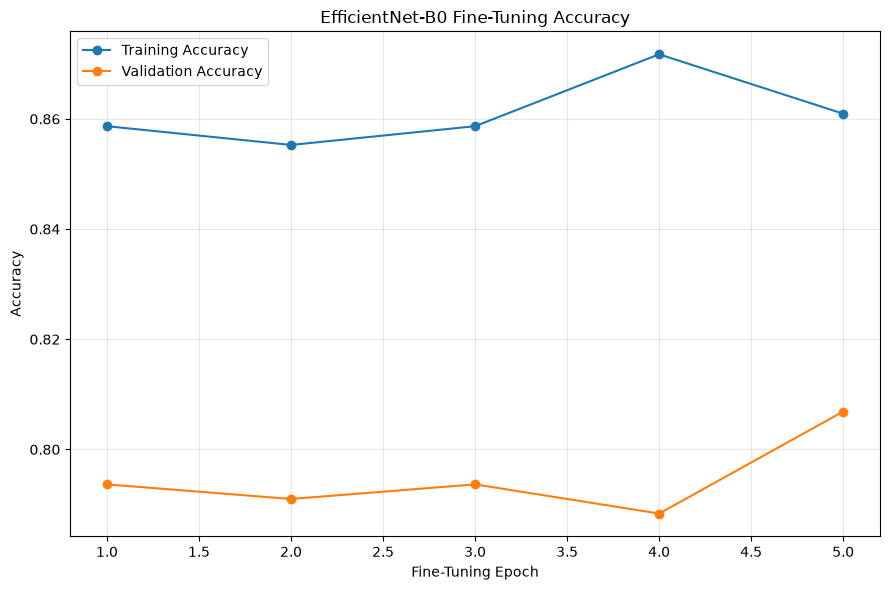

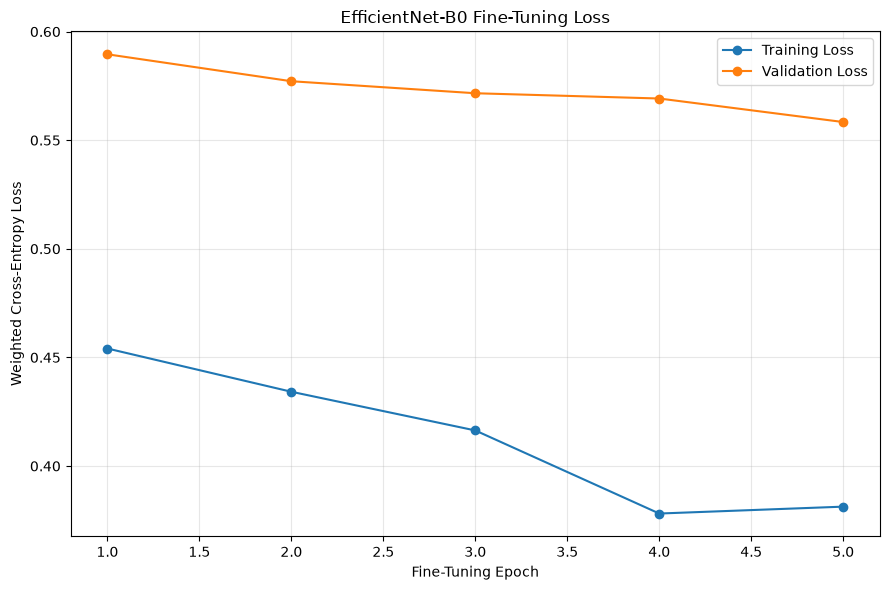

Fine-tuning figures saved:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\figures\efficientnet_b0_fine_tuning_accuracy.png
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\figures\efficientnet_b0_fine_tuning_loss.png


In [132]:
plot_fine_tuning_learning_curves(
    history_dataframe=fine_tuning_history,
    figures_directory=FIGURES_DIRECTORY,
)

In [133]:
best_fine_tuning_row_index = (
    fine_tuning_history[
        "validation_loss"
    ].idxmin()
)

best_fine_tuning_record = (
    fine_tuning_history.loc[
        best_fine_tuning_row_index
    ]
)

best_fine_tuning_epoch = int(
    best_fine_tuning_record["epoch"]
)

best_fine_tuning_validation_loss = float(
    best_fine_tuning_record[
        "validation_loss"
    ]
)

best_fine_tuning_validation_accuracy = float(
    best_fine_tuning_record[
        "validation_accuracy"
    ]
)

print(
    f"Best fine-tuning epoch: "
    f"{best_fine_tuning_epoch}"
)

print(
    f"Best fine-tuning validation loss: "
    f"{best_fine_tuning_validation_loss:.4f}"
)

print(
    f"Validation accuracy at best epoch: "
    f"{best_fine_tuning_validation_accuracy:.4f}"
)

Best fine-tuning epoch: 5
Best fine-tuning validation loss: 0.5584
Validation accuracy at best epoch: 0.8069


In [134]:
validation_comparison = pd.DataFrame(
    [
        {
            "training_stage": (
                "Frozen feature extraction"
            ),
            "best_epoch": (
                frozen_best_epoch
            ),
            "validation_loss": (
                frozen_best_validation_loss
            ),
            "validation_accuracy": (
                frozen_best_validation_accuracy
            ),
        },
        {
            "training_stage": (
                "Controlled fine-tuning"
            ),
            "best_epoch": (
                best_fine_tuning_epoch
            ),
            "validation_loss": (
                best_fine_tuning_validation_loss
            ),
            "validation_accuracy": (
                best_fine_tuning_validation_accuracy
            ),
        },
    ]
)

validation_comparison

,training_stage,best_epoch,validation_loss,validation_accuracy
0,Frozen feature extraction,10,0.625786,0.775132
1,Controlled fine-tuning,5,0.558372,0.806878


In [135]:
validation_accuracy_change = (
    best_fine_tuning_validation_accuracy
    - frozen_best_validation_accuracy
)

validation_loss_change = (
    best_fine_tuning_validation_loss
    - frozen_best_validation_loss
)

print(
    "Validation accuracy change:",
    f"{validation_accuracy_change:+.4f}",
)

print(
    "Validation loss change:",
    f"{validation_loss_change:+.4f}",
)

Validation accuracy change: +0.0317
Validation loss change: -0.0674


In [136]:
fine_tuned_checkpoint = torch.load(
    FINE_TUNED_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

efficientnet_model.load_state_dict(
    fine_tuned_checkpoint[
        "model_state_dict"
    ]
)

efficientnet_model = efficientnet_model.to(
    DEVICE
)

efficientnet_model.eval()

print(
    "Best fine-tuned EfficientNet-B0 "
    "checkpoint restored."
)

print(
    "Checkpoint epoch:",
    fine_tuned_checkpoint["epoch"],
)

print(
    "Validation loss:",
    f"{fine_tuned_checkpoint['validation_loss']:.4f}",
)

print(
    "Validation accuracy:",
    f"{fine_tuned_checkpoint['validation_accuracy']:.4f}",
)

Best fine-tuned EfficientNet-B0 checkpoint restored.
Checkpoint epoch: 5
Validation loss: 0.5584
Validation accuracy: 0.8069


In [137]:
best_fine_tuned_validation_metrics = (
    validate_one_epoch(
        model=efficientnet_model,
        data_loader=validation_loader,
        loss_function=fine_tuning_criterion,
        device=DEVICE,
    )
)

print(
    "Best fine-tuned validation results"
)

print(
    f"Loss     : "
    f"{best_fine_tuned_validation_metrics['loss']:.4f}"
)

print(
    f"Accuracy : "
    f"{best_fine_tuned_validation_metrics['accuracy']:.4f}"
)

print(
    f"Samples  : "
    f"{best_fine_tuned_validation_metrics['sample_count']}"
)

Best fine-tuned validation results
Loss     : 0.5584
Accuracy : 0.8069
Samples  : 378


In [138]:
fine_tuning_configuration = {
    "experiment_name": EXPERIMENT_NAME,
    "architecture": "efficientnet_b0",
    "model_version": MODEL_VERSION,
    "training_stage": "controlled_fine_tuning",
    "starting_checkpoint": str(
        FROZEN_CHECKPOINT_PATH
    ),
    "output_checkpoint": str(
        FINE_TUNED_CHECKPOINT_PATH
    ),
    "fine_tuned_feature_blocks": (
        FINE_TUNE_LAST_N_BLOCKS
    ),
    "first_trainable_block_index": (
        first_trainable_block_index
    ),
    "batch_normalization_frozen": True,
    "backbone_learning_rate": (
        BACKBONE_FINE_TUNE_LEARNING_RATE
    ),
    "classifier_learning_rate": (
        CLASSIFIER_FINE_TUNE_LEARNING_RATE
    ),
    "weight_decay": WEIGHT_DECAY,
    "maximum_epochs": FINE_TUNE_EPOCHS,
    "best_epoch": best_fine_tuning_epoch,
    "best_validation_loss": (
        best_fine_tuning_validation_loss
    ),
    "best_validation_accuracy": (
        best_fine_tuning_validation_accuracy
    ),
    "parameter_summary": (
        fine_tuning_parameter_summary
    ),
}

FINE_TUNING_CONFIGURATION_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_fine_tuning_configuration.json"
)

with open(
    FINE_TUNING_CONFIGURATION_PATH,
    "w",
    encoding="utf-8",
) as configuration_file:
    json.dump(
        fine_tuning_configuration,
        configuration_file,
        indent=4,
    )

print(
    "Fine-tuning configuration saved to:"
)

print(
    FINE_TUNING_CONFIGURATION_PATH.resolve()
)

Fine-tuning configuration saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_fine_tuning_configuration.json


##  Final EfficientNet-B0 Test Evaluation

The best fine-tuned EfficientNet-B0 checkpoint is now evaluated on the isolated
test set.

The test set was not used during:

- Frozen feature extraction
- Fine-tuning
- Checkpoint selection
- Learning-rate adjustment
- Early stopping
- Hyperparameter decisions

This preserves the test set as an unbiased estimate of final generalization
performance.

The evaluation includes:

- Test loss
- Accuracy
- Weighted precision
- Weighted recall
- Weighted F1-score
- Macro precision
- Macro recall
- Macro F1-score
- Multiclass ROC-AUC
- Confusion matrix
- Per-class precision, recall, F1-score, and accuracy
- Prediction confidence analysis
- Class-confusion analysis

In [139]:
if not FINE_TUNED_CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        "The final fine-tuned EfficientNet-B0 checkpoint "
        f"was not found at: {FINE_TUNED_CHECKPOINT_PATH}"
    )

print("Final fine-tuned checkpoint found.")
print(FINE_TUNED_CHECKPOINT_PATH.resolve())

Final fine-tuned checkpoint found.
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\models\efficientnet_b0_finetuned_best.pt


In [140]:
def build_efficientnet_b0_model(
    number_of_classes: int,
    dropout_rate: float,
    device: torch.device,
) -> nn.Module:
    """
    Construct EfficientNet-B0 for TrashNet classification.

    Parameters
    ----------
    number_of_classes:
        Number of target waste classes.

    dropout_rate:
        Dropout probability used in the classifier.

    device:
        CPU or CUDA device.

    Returns
    -------
    nn.Module
        EfficientNet-B0 model with a custom classifier.
    """
    model = efficientnet_b0(
        weights=None
    )

    classifier_input_features = (
        model.classifier[1].in_features
    )

    model.classifier = nn.Sequential(
        nn.Dropout(
            p=dropout_rate
        ),
        nn.Linear(
            in_features=classifier_input_features,
            out_features=number_of_classes,
        ),
    )

    return model.to(device)

In [141]:
final_efficientnet_model = (
    build_efficientnet_b0_model(
        number_of_classes=NUM_CLASSES,
        dropout_rate=DROPOUT_RATE,
        device=DEVICE,
    )
)

print("Final EfficientNet-B0 architecture reconstructed.")

Final EfficientNet-B0 architecture reconstructed.


In [142]:
final_checkpoint = torch.load(
    FINE_TUNED_CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

final_efficientnet_model.load_state_dict(
    final_checkpoint["model_state_dict"]
)

final_efficientnet_model.eval()

print("Final fine-tuned checkpoint loaded successfully.")
print(f"Architecture       : {final_checkpoint['architecture']}")
print(f"Model version      : {final_checkpoint['model_version']}")
print(f"Training stage     : {final_checkpoint['training_stage']}")
print(f"Saved epoch        : {final_checkpoint['epoch']}")
print(f"Validation loss    : {final_checkpoint['validation_loss']:.4f}")
print(f"Validation accuracy: {final_checkpoint['validation_accuracy']:.4f}")

Final fine-tuned checkpoint loaded successfully.
Architecture       : efficientnet_b0
Model version      : 1.0.0
Training stage     : controlled_fine_tuning
Saved epoch        : 5
Validation loss    : 0.5584
Validation accuracy: 0.8069


In [143]:
checkpoint_class_names = final_checkpoint[
    "class_names"
]

checkpoint_class_to_index = final_checkpoint[
    "class_to_index"
]

checkpoint_image_size = tuple(
    final_checkpoint["image_size"]
)

if checkpoint_class_names != class_names:
    raise ValueError(
        "Checkpoint class names do not match "
        "the current notebook class names."
    )

if checkpoint_class_to_index != class_to_index:
    raise ValueError(
        "Checkpoint class mapping does not match "
        "the current notebook mapping."
    )

if checkpoint_image_size != tuple(IMAGE_SIZE):
    raise ValueError(
        "Checkpoint image size does not match "
        "the current experiment image size."
    )

if final_checkpoint["architecture"] != "efficientnet_b0":
    raise ValueError(
        "The loaded checkpoint does not contain "
        "an EfficientNet-B0 model."
    )

print("Checkpoint metadata validation passed.")

Checkpoint metadata validation passed.


In [144]:
final_class_weights = class_weights.to(
    DEVICE
)

final_criterion = nn.CrossEntropyLoss(
    weight=final_class_weights
)

print("Final weighted cross-entropy criterion configured.")

Final weighted cross-entropy criterion configured.


In [145]:
def collect_model_predictions(
    model: nn.Module,
    data_loader: DataLoader,
    loss_function: nn.Module,
    device: torch.device,
) -> dict:
    """
    Evaluate a classification model and collect predictions.

    Parameters
    ----------
    model:
        Trained classification model.

    data_loader:
        Evaluation DataLoader.

    loss_function:
        Classification loss function.

    device:
        CPU or CUDA device.

    Returns
    -------
    dict
        Evaluation metrics and prediction records.
    """
    model.eval()

    running_loss = 0.0
    sample_count = 0

    true_labels = []
    predicted_labels = []
    probability_batches = []
    image_paths = []

    evaluation_start_time = (
        time.perf_counter()
    )

    with torch.inference_mode():
        for batch in data_loader:
            images = batch["image"].to(
                device,
                non_blocking=True,
            )

            labels = batch["label"].to(
                device,
                non_blocking=True,
            )

            logits = model(images)

            loss = loss_function(
                logits,
                labels,
            )

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = torch.argmax(
                probabilities,
                dim=1,
            )

            batch_size = labels.size(0)

            running_loss += (
                loss.item() * batch_size
            )

            sample_count += batch_size

            true_labels.extend(
                labels.cpu().numpy().tolist()
            )

            predicted_labels.extend(
                predictions.cpu().numpy().tolist()
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            image_paths.extend(
                list(batch["path"])
            )

    evaluation_duration_seconds = (
        time.perf_counter()
        - evaluation_start_time
    )

    if sample_count == 0:
        raise RuntimeError(
            "The evaluation DataLoader returned no samples."
        )

    probability_array = np.concatenate(
        probability_batches,
        axis=0,
    )

    return {
        "loss": float(
            running_loss / sample_count
        ),
        "sample_count": int(sample_count),
        "true_labels": np.asarray(
            true_labels,
            dtype=np.int64,
        ),
        "predicted_labels": np.asarray(
            predicted_labels,
            dtype=np.int64,
        ),
        "probabilities": probability_array,
        "image_paths": image_paths,
        "evaluation_duration_seconds": float(
            evaluation_duration_seconds
        ),
    }

In [146]:
test_prediction_output = (
    collect_model_predictions(
        model=final_efficientnet_model,
        data_loader=test_loader,
        loss_function=final_criterion,
        device=DEVICE,
    )
)

test_loss = test_prediction_output["loss"]

true_labels = test_prediction_output[
    "true_labels"
]

predicted_labels = test_prediction_output[
    "predicted_labels"
]

prediction_probabilities = test_prediction_output[
    "probabilities"
]

test_image_paths = test_prediction_output[
    "image_paths"
]

test_evaluation_duration_seconds = (
    test_prediction_output[
        "evaluation_duration_seconds"
    ]
)

print("Test inference completed.")
print(f"Test samples      : {len(true_labels)}")
print(f"Test loss         : {test_loss:.4f}")
print(
    f"Evaluation time   : "
    f"{test_evaluation_duration_seconds:.2f} seconds"
)

Test inference completed.
Test samples      : 381
Test loss         : 0.4272
Evaluation time   : 20.70 seconds


In [147]:
if len(true_labels) != len(predicted_labels):
    raise ValueError(
        "The number of true labels does not match "
        "the number of predicted labels."
    )

if len(true_labels) != len(test_image_paths):
    raise ValueError(
        "The number of image paths does not match "
        "the number of predictions."
    )

if prediction_probabilities.shape != (
    len(true_labels),
    NUM_CLASSES,
):
    raise ValueError(
        "Unexpected probability-array shape. "
        f"Received {prediction_probabilities.shape}."
    )

if not np.isfinite(
    prediction_probabilities
).all():
    raise ValueError(
        "Prediction probabilities contain "
        "NaN or infinite values."
    )

probability_sums = (
    prediction_probabilities.sum(axis=1)
)

if not np.allclose(
    probability_sums,
    1.0,
    atol=1e-5,
):
    raise ValueError(
        "At least one prediction probability row "
        "does not sum to approximately one."
    )

print("Prediction alignment and probability validation passed.")

Prediction alignment and probability validation passed.


In [148]:
test_accuracy = accuracy_score(
    true_labels,
    predicted_labels,
)

(
    weighted_precision,
    weighted_recall,
    weighted_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="weighted",
    zero_division=0,
)

(
    macro_precision,
    macro_recall,
    macro_f1,
    _,
) = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
    average="macro",
    zero_division=0,
)

print("=" * 70)
print("EFFICIENTNET-B0 TEST METRICS")
print("=" * 70)
print(f"Test loss          : {test_loss:.4f}")
print(f"Test accuracy      : {test_accuracy:.4f}")
print(f"Weighted precision : {weighted_precision:.4f}")
print(f"Weighted recall    : {weighted_recall:.4f}")
print(f"Weighted F1-score  : {weighted_f1:.4f}")
print(f"Macro precision    : {macro_precision:.4f}")
print(f"Macro recall       : {macro_recall:.4f}")
print(f"Macro F1-score     : {macro_f1:.4f}")
print("=" * 70)

EFFICIENTNET-B0 TEST METRICS
Test loss          : 0.4272
Test accuracy      : 0.8530
Weighted precision : 0.8626
Weighted recall    : 0.8530
Weighted F1-score  : 0.8550
Macro precision    : 0.8301
Macro recall       : 0.8411
Macro F1-score     : 0.8313


In [149]:
classification_report_dictionary = (
    classification_report(
        true_labels,
        predicted_labels,
        labels=range(NUM_CLASSES),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
)

classification_report_dataframe = (
    pd.DataFrame(
        classification_report_dictionary
    ).transpose()
)

classification_report_dataframe

,precision,recall,f1-score,support
cardboard,0.960784,0.803279,0.875000,61.000000
glass,0.925373,0.826667,0.873239,75.000000
metal,0.852941,0.935484,0.892308,62.000000
paper,0.861702,0.900000,0.880435,90.000000
plastic,0.808219,0.819444,0.813793,72.000000
trash,0.571429,0.761905,0.653061,21.000000
accuracy,0.853018,0.853018,0.853018,0.853018
macro avg,0.830075,0.841130,0.831306,381.000000
weighted avg,0.862567,0.853018,0.854954,381.000000


In [150]:
CLASSIFICATION_REPORT_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_classification_report.csv"
)

classification_report_dataframe.to_csv(
    CLASSIFICATION_REPORT_PATH
)

print(
    "Classification report saved to:"
)

print(
    CLASSIFICATION_REPORT_PATH.resolve()
)

Classification report saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_classification_report.csv


In [151]:
true_labels_one_hot = (
    np.eye(NUM_CLASSES)[true_labels]
)

macro_roc_auc = None
weighted_roc_auc = None

try:
    macro_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="macro",
    )

    weighted_roc_auc = roc_auc_score(
        true_labels_one_hot,
        prediction_probabilities,
        multi_class="ovr",
        average="weighted",
    )

    print(
        f"Macro ROC-AUC   : "
        f"{macro_roc_auc:.4f}"
    )

    print(
        f"Weighted ROC-AUC: "
        f"{weighted_roc_auc:.4f}"
    )

except ValueError as error:
    print(
        "ROC-AUC could not be calculated."
    )
    print(error)

Macro ROC-AUC   : 0.9820
Weighted ROC-AUC: 0.9817


In [152]:
confusion_matrix_values = confusion_matrix(
    true_labels,
    predicted_labels,
    labels=range(NUM_CLASSES),
)

confusion_matrix_dataframe = pd.DataFrame(
    confusion_matrix_values,
    index=class_names,
    columns=class_names,
)

confusion_matrix_dataframe

,cardboard,glass,metal,paper,plastic,trash
cardboard,49,0,1,8,2,1
glass,0,62,2,1,10,0
metal,0,2,58,1,0,1
paper,1,1,2,81,1,4
plastic,0,2,4,1,59,6
trash,1,0,1,2,1,16


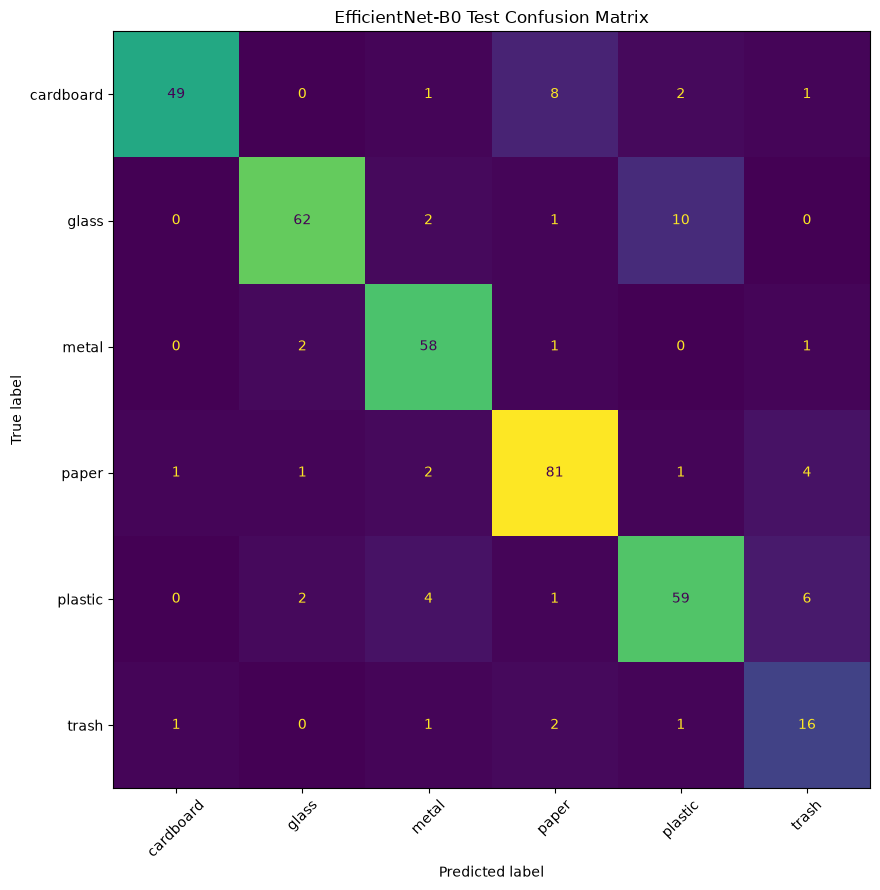

In [153]:
figure, axis = plt.subplots(
    figsize=(10, 9)
)

confusion_display = ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=class_names,
)

confusion_display.plot(
    ax=axis,
    values_format="d",
    xticks_rotation=45,
    colorbar=False,
)

plt.title(
    "EfficientNet-B0 Test Confusion Matrix"
)

plt.tight_layout()

CONFUSION_MATRIX_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "efficientnet_b0_test_confusion_matrix.png"
)

plt.savefig(
    CONFUSION_MATRIX_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [154]:
CONFUSION_MATRIX_CSV_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_confusion_matrix.csv"
)

confusion_matrix_dataframe.to_csv(
    CONFUSION_MATRIX_CSV_PATH
)

print(
    "Confusion matrix files saved successfully."
)

Confusion matrix files saved successfully.


In [155]:
class_test_counts = (
    confusion_matrix_values.sum(axis=1)
)

class_correct_counts = (
    np.diag(confusion_matrix_values)
)

per_class_accuracy = np.divide(
    class_correct_counts,
    class_test_counts,
    out=np.zeros_like(
        class_correct_counts,
        dtype=np.float64,
    ),
    where=class_test_counts != 0,
)

per_class_results = pd.DataFrame(
    {
        "class_index": range(NUM_CLASSES),
        "class_name": class_names,
        "test_samples": class_test_counts,
        "correct_predictions": class_correct_counts,
        "per_class_accuracy": per_class_accuracy,
        "precision": [
            classification_report_dictionary[
                class_name
            ]["precision"]
            for class_name in class_names
        ],
        "recall": [
            classification_report_dictionary[
                class_name
            ]["recall"]
            for class_name in class_names
        ],
        "f1_score": [
            classification_report_dictionary[
                class_name
            ]["f1-score"]
            for class_name in class_names
        ],
    }
)

per_class_results

,class_index,class_name,test_samples,correct_predictions,per_class_accuracy,precision,recall,f1_score
0,0,cardboard,61,49,0.803279,0.960784,0.803279,0.875000
1,1,glass,75,62,0.826667,0.925373,0.826667,0.873239
2,2,metal,62,58,0.935484,0.852941,0.935484,0.892308
3,3,paper,90,81,0.900000,0.861702,0.900000,0.880435
4,4,plastic,72,59,0.819444,0.808219,0.819444,0.813793
5,5,trash,21,16,0.761905,0.571429,0.761905,0.653061


In [156]:
PER_CLASS_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_per_class_results.csv"
)

per_class_results.to_csv(
    PER_CLASS_RESULTS_PATH,
    index=False,
)

print(
    "Per-class results saved to:"
)

print(
    PER_CLASS_RESULTS_PATH.resolve()
)

Per-class results saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_per_class_results.csv


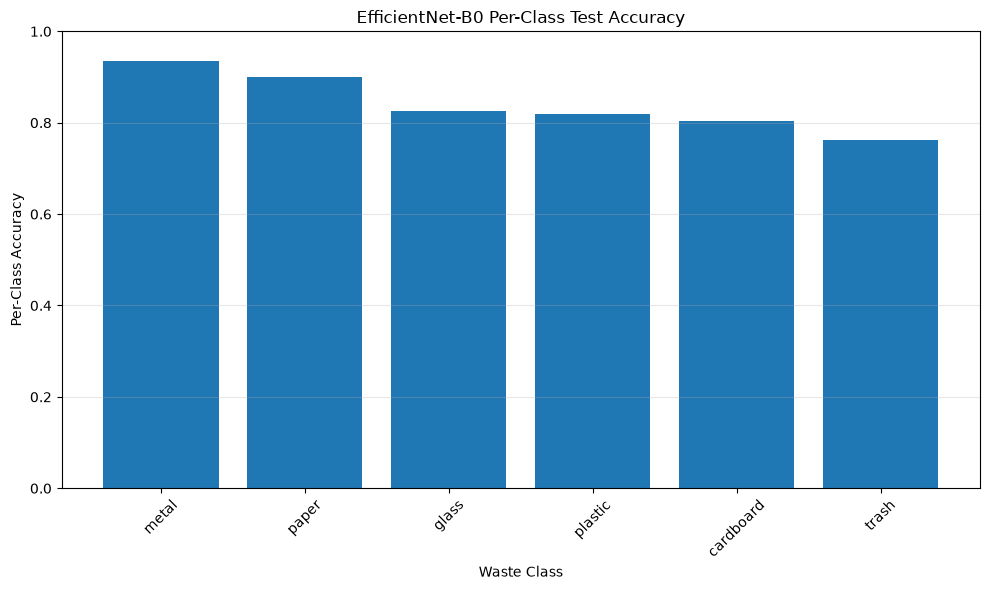

In [157]:
per_class_plot_data = (
    per_class_results.sort_values(
        by="per_class_accuracy",
        ascending=False,
    )
)

plt.figure(figsize=(10, 6))

plt.bar(
    per_class_plot_data["class_name"],
    per_class_plot_data[
        "per_class_accuracy"
    ],
)

plt.ylim(0, 1)
plt.xlabel("Waste Class")
plt.ylabel("Per-Class Accuracy")
plt.title(
    "EfficientNet-B0 Per-Class Test Accuracy"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

PER_CLASS_ACCURACY_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "efficientnet_b0_per_class_accuracy.png"
)

plt.savefig(
    PER_CLASS_ACCURACY_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [158]:
strongest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmax()
    ]
)

weakest_class_record = (
    per_class_results.loc[
        per_class_results[
            "per_class_accuracy"
        ].idxmin()
    ]
)

print(
    "Strongest class:"
)

print(
    f"  Class    : "
    f"{strongest_class_record['class_name']}"
)

print(
    f"  Accuracy : "
    f"{strongest_class_record['per_class_accuracy']:.4f}"
)

print(
    f"  Recall   : "
    f"{strongest_class_record['recall']:.4f}"
)

print()

print(
    "Weakest class:"
)

print(
    f"  Class    : "
    f"{weakest_class_record['class_name']}"
)

print(
    f"  Accuracy : "
    f"{weakest_class_record['per_class_accuracy']:.4f}"
)

print(
    f"  Recall   : "
    f"{weakest_class_record['recall']:.4f}"
)

Strongest class:
  Class    : metal
  Accuracy : 0.9355
  Recall   : 0.9355

Weakest class:
  Class    : trash
  Accuracy : 0.7619
  Recall   : 0.7619


In [159]:
prediction_confidences = (
    prediction_probabilities.max(axis=1)
)

prediction_results = pd.DataFrame(
    {
        "image_path": test_image_paths,
        "true_class_index": true_labels,
        "predicted_class_index": predicted_labels,
        "true_class": [
            index_to_class[int(label)]
            for label in true_labels
        ],
        "predicted_class": [
            index_to_class[int(label)]
            for label in predicted_labels
        ],
        "confidence": prediction_confidences,
        "correct": (
            true_labels == predicted_labels
        ),
    }
)

for class_index, class_name in enumerate(
    class_names
):
    prediction_results[
        f"probability_{class_name}"
    ] = prediction_probabilities[
        :,
        class_index,
    ]

prediction_results.head()

,image_path,true_class_index,predicted_class_index,true_class,predicted_class,confidence,correct,probability_cardboard,probability_glass,probability_metal,probability_paper,probability_plastic,probability_trash
0,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard389.jpg,0,0,cardboard,cardboard,0.909933,True,0.909933,0.012150,0.006272,0.055082,0.010449,0.006114
1,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard234.jpg,0,0,cardboard,cardboard,0.999048,True,0.999048,0.000350,0.000012,0.000329,0.000007,0.000254
2,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard353.jpg,0,0,cardboard,cardboard,0.339469,True,0.339469,0.030497,0.000611,0.299037,0.329097,0.001289
3,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard135.jpg,0,0,cardboard,cardboard,0.869240,True,0.869240,0.001922,0.010866,0.099095,0.004084,0.014793
4,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard273.jpg,0,0,cardboard,cardboard,0.961078,True,0.961078,0.002619,0.002623,0.012444,0.000494,0.020742


In [160]:
PREDICTION_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_test_predictions.csv"
)

prediction_results.to_csv(
    PREDICTION_RESULTS_PATH,
    index=False,
)

print(
    "Prediction-level results saved to:"
)

print(
    PREDICTION_RESULTS_PATH.resolve()
)

Prediction-level results saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_test_predictions.csv


In [168]:
incorrect_predictions = (
    prediction_results[
        prediction_results["correct"] == False
    ]
    .copy()
    .sort_values(
        by="confidence",
        ascending=False,
    )
    .reset_index(drop=True)
)

correct_predictions = (
    prediction_results[
        prediction_results["correct"] == True
    ]
    .copy()
    .sort_values(
        by="confidence",
        ascending=True,
    )
    .reset_index(drop=True)
)

print(
    f"Correct predictions  : "
    f"{len(correct_predictions)}"
)

print(
    f"Incorrect predictions: "
    f"{len(incorrect_predictions)}"
)

print(
    f"Error rate           : "
    f"{len(incorrect_predictions) / len(prediction_results):.4f}"
)

Correct predictions  : 325
Incorrect predictions: 56
Error rate           : 0.1470


In [162]:
confusion_records = []

for true_class_index in range(
    NUM_CLASSES
):
    for predicted_class_index in range(
        NUM_CLASSES
    ):
        if (
            true_class_index
            == predicted_class_index
        ):
            continue

        error_count = int(
            confusion_matrix_values[
                true_class_index,
                predicted_class_index,
            ]
        )

        confusion_records.append(
            {
                "true_class": class_names[
                    true_class_index
                ],
                "predicted_class": class_names[
                    predicted_class_index
                ],
                "error_count": error_count,
            }
        )

class_confusions = (
    pd.DataFrame(
        confusion_records
    )
    .sort_values(
        by="error_count",
        ascending=False,
    )
    .reset_index(drop=True)
)

class_confusions.head(15)

,true_class,predicted_class,error_count
0,glass,plastic,10
1,cardboard,paper,8
2,plastic,trash,6
3,paper,trash,4
4,plastic,metal,4
5,glass,metal,2
6,paper,metal,2
7,metal,glass,2
8,trash,paper,2
9,plastic,glass,2


In [163]:
CLASS_CONFUSIONS_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_class_confusions.csv"
)

class_confusions.to_csv(
    CLASS_CONFUSIONS_PATH,
    index=False,
)

In [164]:
non_zero_confusions = (
    class_confusions[
        class_confusions["error_count"] > 0
    ]
)

if not non_zero_confusions.empty:
    most_frequent_confusion = (
        non_zero_confusions.iloc[0]
    )

    print(
        "Most frequent confusion:"
    )

    print(
        f"  True class      : "
        f"{most_frequent_confusion['true_class']}"
    )

    print(
        f"  Predicted class : "
        f"{most_frequent_confusion['predicted_class']}"
    )

    print(
        f"  Count           : "
        f"{most_frequent_confusion['error_count']}"
    )
else:
    most_frequent_confusion = None
    print(
        "No test-set misclassifications were found."
    )

Most frequent confusion:
  True class      : glass
  Predicted class : plastic
  Count           : 10


In [165]:
confidence_summary = (
    prediction_results
    .groupby("correct")["confidence"]
    .agg(
        [
            "count",
            "mean",
            "median",
            "min",
            "max",
            "std",
        ]
    )
)

confidence_summary.index = (
    confidence_summary.index.map(
        {
            False: "Incorrect",
            True: "Correct",
        }
    )
)

confidence_summary

,count,mean,median,min,max,std
correct,,,,,,
Incorrect,56,0.634038,0.628180,0.298812,0.955714,0.161397
Correct,325,0.874516,0.933319,0.307308,0.999882,0.152047


In [166]:
mean_correct_confidence = float(
    correct_predictions["confidence"].mean()
) if len(correct_predictions) > 0 else None

mean_incorrect_confidence = float(
    incorrect_predictions["confidence"].mean()
) if len(incorrect_predictions) > 0 else None

print(
    f"Mean correct confidence  : "
    f"{mean_correct_confidence:.4f}"
)

if mean_incorrect_confidence is not None:
    print(
        f"Mean incorrect confidence: "
        f"{mean_incorrect_confidence:.4f}"
    )

Mean correct confidence  : 0.8745
Mean incorrect confidence: 0.6340


In [170]:
highest_confidence_errors = (
    incorrect_predictions.head(20)
)

highest_confidence_errors[
    [
        "image_path",
        "true_class",
        "predicted_class",
        "confidence",
    ]
]

,image_path,true_class,predicted_class,confidence
0,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper550.jpg,paper,trash,0.955714
1,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper228.jpg,paper,trash,0.912930
2,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\plastic\plastic40.jpg,plastic,glass,0.906723
3,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\plastic\plastic459.jpg,plastic,trash,0.895732
4,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\metal\metal122.jpg,metal,trash,0.886231
5,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard331.jpg,cardboard,paper,0.880205
6,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard254.jpg,cardboard,paper,0.859457
7,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\glass\glass269.jpg,glass,plastic,0.844426
8,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper370.jpg,paper,glass,0.842427
9,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard190.jpg,cardboard,paper,0.823831


In [171]:
HIGH_CONFIDENCE_ERRORS_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_high_confidence_errors.csv"
)

highest_confidence_errors.to_csv(
    HIGH_CONFIDENCE_ERRORS_PATH,
    index=False,
)

In [172]:
lowest_confidence_correct_predictions = (
    correct_predictions.head(20)
)

lowest_confidence_correct_predictions[
    [
        "image_path",
        "true_class",
        "predicted_class",
        "confidence",
    ]
]

,image_path,true_class,predicted_class,confidence
0,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\glass\glass147.jpg,glass,glass,0.307308
1,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\plastic\plastic164.jpg,plastic,plastic,0.336971
2,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard353.jpg,cardboard,cardboard,0.339469
3,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper463.jpg,paper,paper,0.357827
4,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\glass\glass254.jpg,glass,glass,0.398583
5,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\cardboard\cardboard112.jpg,cardboard,cardboard,0.400552
6,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\plastic\plastic123.jpg,plastic,plastic,0.405014
7,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\glass\glass119.jpg,glass,glass,0.405391
8,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper466.jpg,paper,paper,0.416191
9,C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\data\processed\test\paper\paper199.jpg,paper,paper,0.435521


In [173]:
LOW_CONFIDENCE_CORRECT_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_low_confidence_correct.csv"
)

lowest_confidence_correct_predictions.to_csv(
    LOW_CONFIDENCE_CORRECT_PATH,
    index=False,
)

In [174]:
true_class_distribution = (
    prediction_results[
        "true_class"
    ]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

predicted_class_distribution = (
    prediction_results[
        "predicted_class"
    ]
    .value_counts()
    .reindex(
        class_names,
        fill_value=0,
    )
)

distribution_comparison = pd.DataFrame(
    {
        "true_count": true_class_distribution,
        "predicted_count": (
            predicted_class_distribution
        ),
    }
)

distribution_comparison[
    "count_difference"
] = (
    distribution_comparison[
        "predicted_count"
    ]
    - distribution_comparison[
        "true_count"
    ]
)

distribution_comparison

,true_count,predicted_count,count_difference
cardboard,61,51,-10
glass,75,67,-8
metal,62,68,6
paper,90,94,4
plastic,72,73,1
trash,21,28,7


In [175]:
DISTRIBUTION_COMPARISON_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_prediction_distribution.csv"
)

distribution_comparison.to_csv(
    DISTRIBUTION_COMPARISON_PATH
)

In [176]:
DISTRIBUTION_COMPARISON_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_prediction_distribution.csv"
)

distribution_comparison.to_csv(
    DISTRIBUTION_COMPARISON_PATH
)

In [177]:
def display_prediction_examples(
    prediction_dataframe: pd.DataFrame,
    maximum_images: int = 12,
    title: str = "Prediction Examples",
) -> None:
    """
    Display prediction examples from saved image paths.
    """
    number_of_images = min(
        maximum_images,
        len(prediction_dataframe),
    )

    if number_of_images == 0:
        print(
            "No prediction examples are available."
        )
        return

    number_of_columns = 4
    number_of_rows = int(
        np.ceil(
            number_of_images
            / number_of_columns
        )
    )

    figure, axes = plt.subplots(
        number_of_rows,
        number_of_columns,
        figsize=(
            16,
            4 * number_of_rows,
        ),
    )

    axes = np.asarray(
        axes
    ).reshape(-1)

    for display_index in range(
        number_of_images
    ):
        record = (
            prediction_dataframe.iloc[
                display_index
            ]
        )

        image_path = Path(
            record["image_path"]
        )

        with Image.open(
            image_path
        ) as image:
            image = image.convert("RGB")
            axes[display_index].imshow(
                image
            )

        axes[display_index].set_title(
            "True: "
            f"{record['true_class']}\n"
            "Predicted: "
            f"{record['predicted_class']}\n"
            "Confidence: "
            f"{record['confidence']:.3f}"
        )

        axes[display_index].axis("off")

    for unused_axis in axes[
        number_of_images:
    ]:
        unused_axis.axis("off")

    plt.suptitle(
        title,
        fontsize=16,
    )

    plt.tight_layout()
    plt.show()

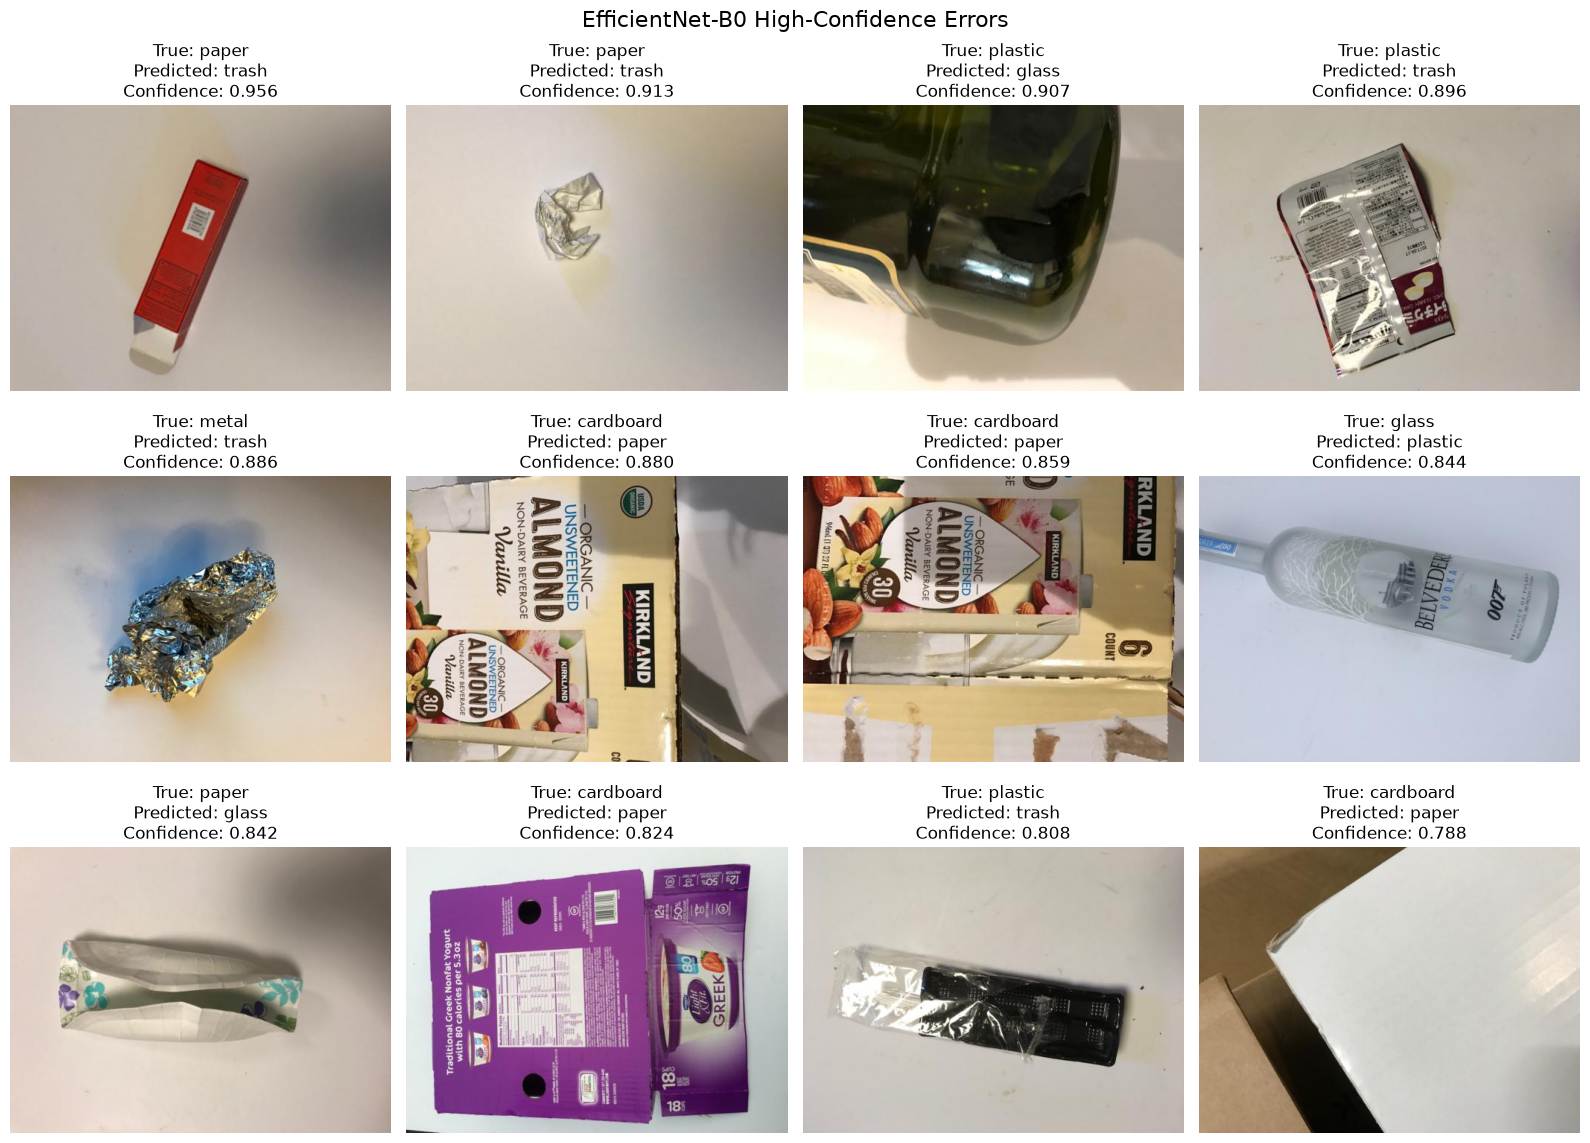

In [178]:
display_prediction_examples(
    prediction_dataframe=(
        highest_confidence_errors
    ),
    maximum_images=12,
    title=(
        "EfficientNet-B0 High-Confidence Errors"
    ),
)

In [180]:
fine_tuned_model_size_bytes = (
    FINE_TUNED_CHECKPOINT_PATH.stat().st_size
)

fine_tuned_model_size_mb = (
    fine_tuned_model_size_bytes
    / (1024 ** 2)
)

print(
    f"Fine-tuned EfficientNet-B0 "
    f"checkpoint size: "
    f"{fine_tuned_model_size_mb:.2f} MB"
)

Fine-tuned EfficientNet-B0 checkpoint size: 24.23 MB


In [181]:
latency_sample_batch = next(
    iter(test_loader)
)

latency_sample_image = (
    latency_sample_batch["image"][:1]
    .to(DEVICE)
)

print(
    "Latency sample shape:",
    latency_sample_image.shape,
)

Latency sample shape: torch.Size([1, 3, 224, 224])


In [182]:
WARM_UP_RUNS = 5

final_efficientnet_model.eval()

with torch.inference_mode():
    for _ in range(
        WARM_UP_RUNS
    ):
        _ = final_efficientnet_model(
            latency_sample_image
        )

print("Inference warm-up completed.")

Inference warm-up completed.


In [183]:
LATENCY_RUNS = 100
latency_measurements_ms = []

with torch.inference_mode():
    for _ in range(
        LATENCY_RUNS
    ):
        start_time = (
            time.perf_counter()
        )

        _ = final_efficientnet_model(
            latency_sample_image
        )

        end_time = (
            time.perf_counter()
        )

        latency_measurements_ms.append(
            (
                end_time
                - start_time
            )
            * 1000
        )

mean_latency_ms = float(
    np.mean(
        latency_measurements_ms
    )
)

median_latency_ms = float(
    np.median(
        latency_measurements_ms
    )
)

latency_standard_deviation_ms = float(
    np.std(
        latency_measurements_ms
    )
)

latency_95th_percentile_ms = float(
    np.percentile(
        latency_measurements_ms,
        95,
    )
)

print(
    f"Mean latency           : "
    f"{mean_latency_ms:.2f} ms"
)

print(
    f"Median latency         : "
    f"{median_latency_ms:.2f} ms"
)

print(
    f"Latency standard dev.  : "
    f"{latency_standard_deviation_ms:.2f} ms"
)

print(
    f"95th-percentile latency: "
    f"{latency_95th_percentile_ms:.2f} ms"
)

Mean latency           : 39.16 ms
Median latency         : 37.78 ms
Latency standard dev.  : 6.56 ms
95th-percentile latency: 51.97 ms


In [184]:
predictions_per_second = (
    1000 / mean_latency_ms
)

print(
    f"Approximate single-image throughput: "
    f"{predictions_per_second:.2f} "
    "predictions per second"
)

Approximate single-image throughput: 25.54 predictions per second


In [185]:
final_parameter_summary = (
    count_model_parameters(
        final_efficientnet_model
    )
)

print(
    "Final EfficientNet-B0 parameter summary:"
)

for parameter_name, parameter_value in (
    final_parameter_summary.items()
):
    print(
        f"{parameter_name}: "
        f"{parameter_value:,}"
    )

Final EfficientNet-B0 parameter summary:
total_parameters: 4,015,234
trainable_parameters: 4,015,234
frozen_parameters: 0


In [186]:
most_frequent_confusion_record = None

if (
    most_frequent_confusion
    is not None
):
    most_frequent_confusion_record = {
        "true_class": str(
            most_frequent_confusion[
                "true_class"
            ]
        ),
        "predicted_class": str(
            most_frequent_confusion[
                "predicted_class"
            ]
        ),
        "count": int(
            most_frequent_confusion[
                "error_count"
            ]
        ),
    }

In [187]:
efficientnet_final_results = {
    "experiment": {
        "experiment_name": EXPERIMENT_NAME,
        "architecture": "efficientnet_b0",
        "model_version": MODEL_VERSION,
        "framework": "PyTorch",
        "pytorch_version": (
            torch.__version__
        ),
        "torchvision_version": (
            torchvision.__version__
        ),
        "device": str(DEVICE),
        "completed_at": (
            datetime.now().isoformat()
        ),
    },

    "dataset": {
        "dataset_name": "TrashNet",
        "number_of_classes": NUM_CLASSES,
        "class_names": class_names,
        "training_images": len(
            train_dataset
        ),
        "validation_images": len(
            validation_dataset
        ),
        "test_images": len(
            test_dataset
        ),
        "image_size": list(
            IMAGE_SIZE
        ),
    },

    "frozen_stage": {
        "best_epoch": (
            frozen_best_epoch
        ),
        "best_validation_loss": (
            frozen_best_validation_loss
        ),
        "best_validation_accuracy": (
            frozen_best_validation_accuracy
        ),
        "classifier_learning_rate": (
            HEAD_LEARNING_RATE
        ),
    },

    "fine_tuning_stage": {
        "fine_tuned_feature_blocks": (
            FINE_TUNE_LAST_N_BLOCKS
        ),
        "first_trainable_block_index": (
            first_trainable_block_index
        ),
        "batch_normalization_frozen": True,
        "backbone_learning_rate": (
            BACKBONE_FINE_TUNE_LEARNING_RATE
        ),
        "classifier_learning_rate": (
            CLASSIFIER_FINE_TUNE_LEARNING_RATE
        ),
        "best_epoch": (
            best_fine_tuning_epoch
        ),
        "best_validation_loss": (
            best_fine_tuning_validation_loss
        ),
        "best_validation_accuracy": (
            best_fine_tuning_validation_accuracy
        ),
    },

    "test_metrics": {
        "loss": float(test_loss),
        "accuracy": float(
            test_accuracy
        ),
        "weighted_precision": float(
            weighted_precision
        ),
        "weighted_recall": float(
            weighted_recall
        ),
        "weighted_f1_score": float(
            weighted_f1
        ),
        "macro_precision": float(
            macro_precision
        ),
        "macro_recall": float(
            macro_recall
        ),
        "macro_f1_score": float(
            macro_f1
        ),
        "macro_roc_auc": (
            float(macro_roc_auc)
            if macro_roc_auc is not None
            else None
        ),
        "weighted_roc_auc": (
            float(weighted_roc_auc)
            if weighted_roc_auc
            is not None
            else None
        ),
    },

    "class_analysis": {
        "strongest_class": {
            "class_name": str(
                strongest_class_record[
                    "class_name"
                ]
            ),
            "per_class_accuracy": float(
                strongest_class_record[
                    "per_class_accuracy"
                ]
            ),
        },
        "weakest_class": {
            "class_name": str(
                weakest_class_record[
                    "class_name"
                ]
            ),
            "per_class_accuracy": float(
                weakest_class_record[
                    "per_class_accuracy"
                ]
            ),
        },
        "most_frequent_confusion": (
            most_frequent_confusion_record
        ),
        "correct_predictions": int(
            prediction_results[
                "correct"
            ].sum()
        ),
        "incorrect_predictions": int(
            (
                prediction_results[
                    "correct"
                ]
                == False
            ).sum()
        ),
        "mean_correct_confidence": (
            float(
                mean_correct_confidence
            )
            if mean_correct_confidence
            is not None
            else None
        ),
        "mean_incorrect_confidence": (
            float(
                mean_incorrect_confidence
            )
            if mean_incorrect_confidence
            is not None
            else None
        ),
    },

    "deployment_metrics": {
        "checkpoint_size_mb": float(
            fine_tuned_model_size_mb
        ),
        "total_parameters": int(
            final_parameter_summary[
                "total_parameters"
            ]
        ),
        "mean_latency_ms": float(
            mean_latency_ms
        ),
        "median_latency_ms": float(
            median_latency_ms
        ),
        "latency_standard_deviation_ms": float(
            latency_standard_deviation_ms
        ),
        "latency_95th_percentile_ms": float(
            latency_95th_percentile_ms
        ),
        "predictions_per_second": float(
            predictions_per_second
        ),
        "latency_runs": int(
            LATENCY_RUNS
        ),
    },

    "artifacts": {
        "checkpoint": str(
            FINE_TUNED_CHECKPOINT_PATH
        ),
        "classification_report": str(
            CLASSIFICATION_REPORT_PATH
        ),
        "confusion_matrix_csv": str(
            CONFUSION_MATRIX_CSV_PATH
        ),
        "confusion_matrix_figure": str(
            CONFUSION_MATRIX_FIGURE_PATH
        ),
        "per_class_results": str(
            PER_CLASS_RESULTS_PATH
        ),
        "prediction_results": str(
            PREDICTION_RESULTS_PATH
        ),
    },
}

In [188]:
FINAL_RESULTS_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_final_results.json"
)

with open(
    FINAL_RESULTS_PATH,
    "w",
    encoding="utf-8",
) as results_file:
    json.dump(
        efficientnet_final_results,
        results_file,
        indent=4,
    )

print(
    "Final EfficientNet-B0 results saved to:"
)

print(
    FINAL_RESULTS_PATH.resolve()
)

Final EfficientNet-B0 results saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_final_results.json


In [189]:
efficientnet_comparison_row = pd.DataFrame(
    [
        {
            "model_name": "EfficientNet-B0",
            "architecture": "efficientnet_b0",
            "training_stage": (
                "controlled_fine_tuning"
            ),
            "test_loss": test_loss,
            "test_accuracy": (
                test_accuracy
            ),
            "weighted_precision": (
                weighted_precision
            ),
            "weighted_recall": (
                weighted_recall
            ),
            "weighted_f1_score": (
                weighted_f1
            ),
            "macro_precision": (
                macro_precision
            ),
            "macro_recall": (
                macro_recall
            ),
            "macro_f1_score": (
                macro_f1
            ),
            "macro_roc_auc": (
                macro_roc_auc
            ),
            "weighted_roc_auc": (
                weighted_roc_auc
            ),
            "model_size_mb": (
                fine_tuned_model_size_mb
            ),
            "total_parameters": (
                final_parameter_summary[
                    "total_parameters"
                ]
            ),
            "mean_inference_latency_ms": (
                mean_latency_ms
            ),
            "median_inference_latency_ms": (
                median_latency_ms
            ),
            "predictions_per_second": (
                predictions_per_second
            ),
            "best_validation_accuracy": (
                best_fine_tuning_validation_accuracy
            ),
            "best_validation_loss": (
                best_fine_tuning_validation_loss
            ),
        }
    ]
)

efficientnet_comparison_row

,model_name,architecture,training_stage,test_loss,test_accuracy,weighted_precision,weighted_recall,weighted_f1_score,macro_precision,macro_recall,macro_f1_score,macro_roc_auc,weighted_roc_auc,model_size_mb,total_parameters,mean_inference_latency_ms,median_inference_latency_ms,predictions_per_second,best_validation_accuracy,best_validation_loss
0,EfficientNet-B0,efficientnet_b0,controlled_fine_tuning,0.427249,0.853018,0.862567,0.853018,0.854954,0.830075,0.84113,0.831306,0.982026,0.981699,24.230475,4015234,39.156232,37.78455,25.538719,0.806878,0.558372


In [190]:
EFFICIENTNET_COMPARISON_ROW_PATH = (
    RESULTS_DIRECTORY
    / "efficientnet_b0_comparison_row.csv"
)

efficientnet_comparison_row.to_csv(
    EFFICIENTNET_COMPARISON_ROW_PATH,
    index=False,
)

print(
    "EfficientNet-B0 comparison row saved to:"
)

print(
    EFFICIENTNET_COMPARISON_ROW_PATH.resolve()
)

EfficientNet-B0 comparison row saved to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\efficientnet_b0_comparison_row.csv


In [191]:
final_summary_table = pd.DataFrame(
    [
        {
            "Metric": "Test loss",
            "Value": f"{test_loss:.4f}",
        },
        {
            "Metric": "Test accuracy",
            "Value": f"{test_accuracy:.4f}",
        },
        {
            "Metric": "Weighted precision",
            "Value": f"{weighted_precision:.4f}",
        },
        {
            "Metric": "Weighted recall",
            "Value": f"{weighted_recall:.4f}",
        },
        {
            "Metric": "Weighted F1-score",
            "Value": f"{weighted_f1:.4f}",
        },
        {
            "Metric": "Macro F1-score",
            "Value": f"{macro_f1:.4f}",
        },
        {
            "Metric": "Macro ROC-AUC",
            "Value": (
                f"{macro_roc_auc:.4f}"
                if macro_roc_auc
                is not None
                else "Not available"
            ),
        },
        {
            "Metric": "Model size",
            "Value": (
                f"{fine_tuned_model_size_mb:.2f} MB"
            ),
        },
        {
            "Metric": "Mean latency",
            "Value": (
                f"{mean_latency_ms:.2f} ms"
            ),
        },
        {
            "Metric": "Total parameters",
            "Value": (
                f"{final_parameter_summary['total_parameters']:,}"
            ),
        },
    ]
)

final_summary_table

,Metric,Value
0,Test loss,0.4272
1,Test accuracy,0.8530
2,Weighted precision,0.8626
3,Weighted recall,0.8530
4,Weighted F1-score,0.8550
5,Macro F1-score,0.8313
6,Macro ROC-AUC,0.9820
7,Model size,24.23 MB
8,Mean latency,39.16 ms
9,Total parameters,"4,015,234"


In [193]:
PREDICTION_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "efficientnet_b0_prediction_distribution.png"
)

print(PREDICTION_DISTRIBUTION_FIGURE_PATH)

..\results\figures\efficientnet_b0_prediction_distribution.png


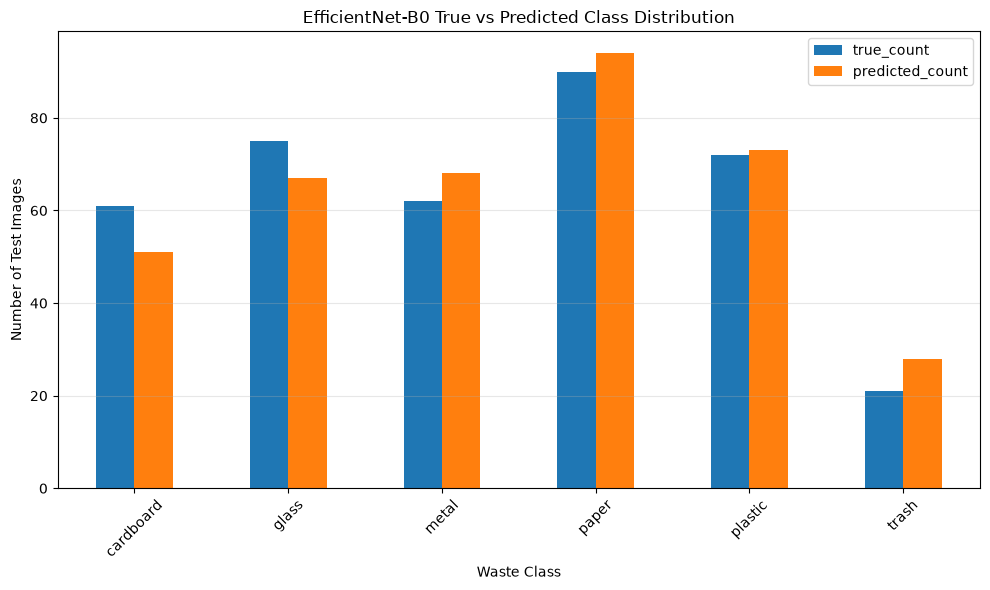

Saved figure to:
C:\Users\Mudassar Iqbal Shah\Documents\Internship\smart-waste-classification\results\figures\efficientnet_b0_prediction_distribution.png
Exists: True


In [203]:
PREDICTION_DISTRIBUTION_FIGURE_PATH = (
    FIGURES_DIRECTORY
    / "efficientnet_b0_prediction_distribution.png"
)

if "distribution_comparison" not in globals():
    true_class_distribution = (
        prediction_results["true_class"]
        .value_counts()
        .reindex(class_names, fill_value=0)
    )

    predicted_class_distribution = (
        prediction_results["predicted_class"]
        .value_counts()
        .reindex(class_names, fill_value=0)
    )

    distribution_comparison = pd.DataFrame(
        {
            "true_count": true_class_distribution,
            "predicted_count": predicted_class_distribution,
        }
    )

    distribution_comparison["count_difference"] = (
        distribution_comparison["predicted_count"]
        - distribution_comparison["true_count"]
    )

ax = distribution_comparison[
    ["true_count", "predicted_count"]
].plot(
    kind="bar",
    figsize=(10, 6),
)

ax.set_xlabel("Waste Class")
ax.set_ylabel("Number of Test Images")
ax.set_title(
    "EfficientNet-B0 True vs Predicted Class Distribution"
)

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig(
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved figure to:")
print(PREDICTION_DISTRIBUTION_FIGURE_PATH.resolve())
print("Exists:", PREDICTION_DISTRIBUTION_FIGURE_PATH.exists())

In [205]:
expected_efficientnet_artifacts = [
    FROZEN_CHECKPOINT_PATH,
    FINE_TUNED_CHECKPOINT_PATH,
    FROZEN_HISTORY_PATH,
    FINE_TUNING_HISTORY_PATH,
    frozen_configuration_path,
    FINE_TUNING_CONFIGURATION_PATH,
    CLASSIFICATION_REPORT_PATH,
    CONFUSION_MATRIX_CSV_PATH,
    CONFUSION_MATRIX_FIGURE_PATH,
    PER_CLASS_RESULTS_PATH,
    PER_CLASS_ACCURACY_FIGURE_PATH,
    PREDICTION_RESULTS_PATH,
    CLASS_CONFUSIONS_PATH,
    HIGH_CONFIDENCE_ERRORS_PATH,
    LOW_CONFIDENCE_CORRECT_PATH,
    DISTRIBUTION_COMPARISON_PATH,
    PREDICTION_DISTRIBUTION_FIGURE_PATH,
    FINAL_RESULTS_PATH,
    EFFICIENTNET_COMPARISON_ROW_PATH,
]

artifact_verification = pd.DataFrame(
    [
        {
            "artifact": str(artifact_path),
            "exists": artifact_path.exists(),
            "size_kb": (
                artifact_path.stat().st_size / 1024
                if artifact_path.exists()
                else None
            ),
        }
        for artifact_path in expected_efficientnet_artifacts
    ]
)

display(artifact_verification)

missing_artifacts = artifact_verification[
    artifact_verification["exists"] == False
]

if not missing_artifacts.empty:
    display(missing_artifacts)

    raise FileNotFoundError(
        "One or more required EfficientNet-B0 "
        "artifacts were not created."
    )

print(
    "All expected EfficientNet-B0 artifacts "
    "were created successfully."
)

,artifact,exists,size_kb
0,..\models\efficientnet_b0_frozen_best.pt,True,16041.237305
1,..\models\efficientnet_b0_finetuned_best.pt,True,24812.006836
2,..\logs\efficientnet_b0_frozen_history.csv,True,1.179688
3,..\logs\efficientnet_b0_fine_tuning_history.csv,True,0.712891
4,..\results\efficientnet_b0_frozen_configuration.json,True,0.858398
5,..\results\efficientnet_b0_fine_tuning_configuration.json,True,0.824219
6,..\results\efficientnet_b0_classification_report.csv,True,0.648438
7,..\results\efficientnet_b0_confusion_matrix.csv,True,0.166992
8,..\results\figures\efficientnet_b0_test_confusion_matrix.png,True,130.942383
9,..\results\efficientnet_b0_per_class_results.csv,True,0.596680


All expected EfficientNet-B0 artifacts were created successfully.


In [206]:
missing_artifacts = artifact_verification[
    artifact_verification["exists"] == False
]

if not missing_artifacts.empty:
    display(
        missing_artifacts
    )

    raise FileNotFoundError(
        "One or more required EfficientNet-B0 "
        "artifacts were not created."
    )

print(
    "All expected EfficientNet-B0 artifacts "
    "were created successfully."
)

All expected EfficientNet-B0 artifacts were created successfully.
